### Tải dữ liệu và cài đặt ban đầu

Phần này thiết lập môi trường bằng cách kết nối Google Drive, định nghĩa các đường dẫn đến các tập tin dữ liệu nguyên thủy (CSV và JSON) và sau đó tải chúng vào các DataFrame của pandas. Các tệp dữ liệu bao gồm thông tin về chất lượng nước (CSDL_DSS1) và mực nước từ nhiều trạm thủy văn khác nhau.

In [ ]:
import numpy as np
import pandas as pd
from google.colab import drive

# 1. Kết nối với Google Drive
drive.mount('/content/drive')

# 2. Định nghĩa đường dẫn đến file
# Lưu ý: "Drive của tôi" trong Colab sẽ là "MyDrive"
file_path1 = '/content/drive/MyDrive/XNM/RawData/CSDL_DSS1_20240109_1.csv'
file_path2 = '/content/drive/MyDrive/XNM/RawData/tanChauwaterLevel2016.json'
file_path3 = '/content/drive/MyDrive/XNM/RawData/ViThanh_WaterLevel_2018_2026_15min.csv'
file_path4 = '/content/drive/MyDrive/XNM/RawData/TraVinh_WaterLevel_2022_2026_15min.csv'
file_path5 = '/content/drive/MyDrive/XNM/RawData/PhungHiep_WaterLevel_2018_2026_15min.csv'
file_path6 = '/content/drive/MyDrive/XNM/RawData/MyThuan_WaterLevel_2018_2026_15min.csv'
file_path7 = '/content/drive/MyDrive/XNM/RawData/GiangSon_WaterLevel_2018_2026_15min.csv'
file_path8 = '/content/drive/MyDrive/XNM/RawData/DucXuyen_WaterLevel_2018_2026_15min.csv'
file_path9 = '/content/drive/MyDrive/XNM/RawData/DaiNgai_WaterLevel_2022_2026_15min.csv'
file_path10 = '/content/drive/MyDrive/XNM/RawData/ChoLach_WaterLevel_2018_2026_15min.csv'
file_path11 = '/content/drive/MyDrive/XNM/RawData/ChauDoc_WaterLevel_2018_2026_15min.csv'
file_path12 = '/content/drive/MyDrive/XNM/RawData/CanTho_WaterLevel_2018_2026_15min.csv'

# 3. Đọc file CSV thành DataFrame
df = pd.read_csv(file_path1)
df_tanchau = pd.read_json(file_path2)
df_vithanh = pd.read_csv(file_path3)
df_travinh = pd.read_csv(file_path4)
df_phunghiep = pd.read_csv(file_path5)
df_mythuan = pd.read_csv(file_path6)
df_giangson = pd.read_csv(file_path7)
df_ducxuyen = pd.read_csv(file_path8)
df_daingai = pd.read_csv(file_path9)
df_cholach = pd.read_csv(file_path10)
df_chaudoc = pd.read_csv(file_path11)
df_cantho = pd.read_csv(file_path12)

Mounted at /content/drive


### Kiểm tra dữ liệu ban đầu và chọn lọc Features

Phần này thực hiện kiểm tra sơ bộ DataFrame chính (`df`) bằng `df.info()` để hiểu cấu trúc và kiểu dữ liệu. Sau đó, nó loại bỏ dòng đầu tiên (chứa đơn vị) và chỉ giữ lại một tập hợp các cột đã chọn (`Matram`, `longitude`, `latitude`, `Z.Elev`, `Date`, `Salinity`, `CL`, `TSS`) để làm sạch dữ liệu ban đầu.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2697 entries, 0 to 2696
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Matram             2696 non-null   object 
 1   Kyhieu             2696 non-null   object 
 2   longitude          2697 non-null   object 
 3   latitude           2697 non-null   object 
 4   Z.Elev             2697 non-null   object 
 5   Date               2696 non-null   object 
 6   pH                 2696 non-null   float64
 7   Aldrin             2697 non-null   object 
 8   BHC                2697 non-null   object 
 9   Dieldrin           2697 non-null   object 
 10  DDTs               2697 non-null   object 
 11  Heptachlor         2697 non-null   object 
 12  Heptachlorepoxide  2697 non-null   object 
 13  As                 2697 non-null   object 
 14  Cd                 2697 non-null   object 
 15  Pb                 2697 non-null   object 
 16  Cr6                2697 

### Phần 1: Chọn lọc Features

In [ ]:
# 2. Loại bỏ dòng index 0 (chứa đơn vị như degree, mg/L, ‰...)
df = df.drop(index=0).reset_index(drop=True)
cols_to_keep = [
    'Matram', 'longitude', 'latitude', 'Z.Elev', 'Date',
    'Salinity', 'CL', 'TSS'
]
df_clean = df[cols_to_keep].copy()
df_clean

,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS
0,QLPH012016,105.68,9.3,0.66,29/2/2016,3.6,1949,4.4
1,QLPH012016,105.68,9.3,0.66,15/3/2016,4.6,271.29,72.52
2,QLPH012016,105.68,9.3,0.66,2/4/2016,5.4,3261.4,115.6
3,QLPH012016,105.68,9.3,0.66,15/4/2016,5.1,3819,76.52
4,QLPH012016,105.68,9.3,0.66,2/5/2016,5.6,3574,52.6
...,...,...,...,...,...,...,...,...
2691,BD00142021,106.45,10.35,0.33,29/1/2021,3.1,673.5,0.76
2692,BD00152021,106.33,10.34,0.35,29/1/2021,0.35,53.49,0.8
2693,BD00162021,106.25,10.42,0.35,29/1/2021,0.16,22.65,0.73
2694,BD00172021,106.33,10.48,0.35,29/1/2021,0.12,16.5,0.66


### Phần 2: Ép kiểu dữ liệu & Xử lý thời gian

### Chuyển đổi kiểu dữ liệu và xử lý thời gian

Bước này chuyển đổi các cột số (`longitude`, `latitude`, `Z.Elev`, `Salinity`, `CL`, `TSS`) sang kiểu `float` và cột `Date` sang kiểu `datetime`. Các giá trị không hợp lệ sẽ được chuyển thành `NaN`. Cuối cùng, các hàng chứa `NaN` trong cột `Date` hoặc `Matram` sẽ được loại bỏ để đảm bảo chất lượng dữ liệu.

In [ ]:
# 1. Định nghĩa các cột dạng số
numeric_cols = ['longitude', 'latitude', 'Z.Elev', 'Salinity', 'CL', 'TSS']

# Ép kiểu dữ liệu sang float, nếu có ký tự lạ (như '-', khoảng trắng) sẽ bị ép thành NaN (Not a Number)
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 2. Chuyển đổi cột Date sang định dạng Datetime
# format đang là Ngày/Tháng/Năm (vd: 29/2/2016)
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y', errors='coerce')

# 3. Loại bỏ các dòng rác không chứa thông tin ngày tháng hoặc mã trạm
df_clean = df_clean.dropna(subset=['Date', 'Matram'])
df_clean.head(10)

,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS
0,QLPH012016,105.68,9.30,0.66,2016-02-29,3.6,1949.00,4.40
1,QLPH012016,105.68,9.30,0.66,2016-03-15,4.6,271.29,72.52
2,QLPH012016,105.68,9.30,0.66,2016-04-02,5.4,3261.40,115.60
3,QLPH012016,105.68,9.30,0.66,2016-04-15,5.1,3819.00,76.52
4,QLPH012016,105.68,9.30,0.66,2016-05-02,5.6,3574.00,52.60
5,QLPH012016,105.68,9.30,0.66,2016-05-16,3.0,1391.20,45.62
6,QLPH012016,105.68,9.30,0.66,2016-06-02,2.2,1195.60,125.50
7,QLPH012016,105.68,9.30,0.66,2016-06-15,1.2,795.40,87.20
8,QLPH022016,105.53,9.26,0.54,2016-02-29,1.6,918.00,56.21
9,QLPH022016,105.53,9.26,0.54,2016-03-15,1.7,16.78,67.25


### Phần 3: Tiền xử lý bất thường Độ mặn & Clorua

### Tiền xử lý bất thường cho Độ mặn và Clorua

Phần này xử lý các giá trị bất thường trong cột `Salinity` (độ mặn) và `CL` (clorua). Nó sử dụng các quy tắc vật lý như hệ thức Knudsen để chuyển đổi các giá trị `0` "ngụy trang" thành `NaN` nếu chúng mâu thuẫn với các giá trị khác. Mục đích là làm sạch dữ liệu trước khi nội suy.

In [ ]:
# 1. Đưa các giá trị 0 ngụy trang về dạng NaN để tránh nhiễu model
# Trực quan: Nếu mặn > 0 mà Clo = 0 -> Clo bị đo lỗi
df_clean.loc[(df_clean['Salinity'] > 0) & (df_clean['CL'] == 0), 'CL'] = np.nan

# Trực quan: Nếu Clo > 0 mà mặn = 0 -> Mặn bị đo lỗi (dưới ngưỡng phát hiện của máy đo)
df_clean.loc[(df_clean['CL'] > 0) & (df_clean['Salinity'] == 0), 'Salinity'] = np.nan
df_clean

,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS
0,QLPH012016,105.68,9.30,0.66,2016-02-29,3.60,1949.00,4.40
1,QLPH012016,105.68,9.30,0.66,2016-03-15,4.60,271.29,72.52
2,QLPH012016,105.68,9.30,0.66,2016-04-02,5.40,3261.40,115.60
3,QLPH012016,105.68,9.30,0.66,2016-04-15,5.10,3819.00,76.52
4,QLPH012016,105.68,9.30,0.66,2016-05-02,5.60,3574.00,52.60
...,...,...,...,...,...,...,...,...
2691,BD00142021,106.45,10.35,0.33,2021-01-29,3.10,673.50,0.76
2692,BD00152021,106.33,10.34,0.35,2021-01-29,0.35,53.49,0.80
2693,BD00162021,106.25,10.42,0.35,2021-01-29,0.16,22.65,0.73
2694,BD00172021,106.33,10.48,0.35,2021-01-29,0.12,16.50,0.66


### Phần 3.5: Lấp khuyết (Impute) dữ liệu NaN cho Salinity và CL

### Lấp khuyết (Impute) dữ liệu NaN cho Salinity và CL

Để xử lý các giá trị `NaN` còn lại trong `Salinity` và `CL`, phần này áp dụng hai chiến lược:
1.  **Nội suy chéo vật lý**: Dựa trên hệ thức Knudsen để điền `NaN` của `Salinity` từ `CL` và ngược lại.
2.  **Nội suy chuỗi thời gian**: Đối với các trường hợp `NaN` cả `Salinity` và `CL`, dữ liệu được sắp xếp theo trạm và thời gian, sau đó sử dụng nội suy tuyến tính (`linear interpolation`) trong phạm vi 3 ngày và `bfill/ffill` để điền nốt các giá trị còn thiếu trong từng trạm.

In [ ]:
print(f"Số lượng NaN trước xử lý: Salinity ({df_clean['Salinity'].isna().sum()}), CL ({df_clean['CL'].isna().sum()})")

# ==========================================
# CHIẾN LƯỢC 1: NỘI SUY CHÉO VẬT LÝ
# Dựa trên hệ thức Knudsen của Hải dương học: Độ mặn (‰) ≈  0.00180665 × Clorua (mg/l)
# ==========================================

# 1.1 Điền Salinity bị NaN dựa vào giá trị CL hiện có
cond_sal_nan = df_clean['Salinity'].isna() & df_clean['CL'].notna()
df_clean.loc[cond_sal_nan, 'Salinity'] = df_clean.loc[cond_sal_nan, 'CL'] *  0.00180665

# 1.2 Điền CL bị NaN dựa vào giá trị Salinity hiện có
cond_cl_nan = df_clean['CL'].isna() & df_clean['Salinity'].notna()
df_clean.loc[cond_cl_nan, 'CL'] = (df_clean.loc[cond_cl_nan, 'Salinity'] /  0.00180665)


# ==========================================
# CHIẾN LƯỢC 2: NỘI SUY CHUỖI THỜI GIAN THEO TRẠM
# Dành cho các dòng bị NaN cả Salinity lẫn CL
# ==========================================

# sort dữ liệu theo Trạm và Thời gian thì hàm Interpolate mới chạy đúng logic vật lý
df_clean = df_clean.sort_values(by=['Matram', 'Date']).reset_index(drop=True)

# Dùng groupby để gom theo từng trạm, sau đó nội suy tuyến tính (linear)
# limit=3: Chỉ nội suy tối đa 3 ngày liên tiếp bị thiếu để tránh bịa data quá đà
df_clean[['Salinity', 'CL']] = df_clean.groupby('Matram')[['Salinity', 'CL']].apply(
    lambda group: group.interpolate(method='linear', limit=3, limit_direction='both')
).reset_index(drop=True)

# Lỡ còn sót lại NaN nào do ở đầu/cuối chuỗi dữ liệu của trạm đó, fill bằng 0 hoặc trung bình trạm
# Ở đây ta lấp nốt bằng backward/forward fill trong chính trạm đó
df_clean[['Salinity', 'CL']] = df_clean.groupby('Matram')[['Salinity', 'CL']].apply(
    lambda group: group.bfill().ffill()
).reset_index(drop=True)

print(f"Số lượng NaN sau xử lý: Salinity ({df_clean['Salinity'].isna().sum()}), CL ({df_clean['CL'].isna().sum()})")

Số lượng NaN trước xử lý: Salinity (665), CL (323)
Số lượng NaN sau xử lý: Salinity (0), CL (0)


In [ ]:
df_clean.head()

,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS
0,BD00012019,106.58,10.43,0.95,2019-03-04,8.1,746.80,35.21
1,BD00012019,106.58,10.43,0.95,2019-03-18,9.0,921.00,25.12
2,BD00012019,106.58,10.43,0.95,2019-04-02,8.0,91.56,32.15
3,BD00012019,106.58,10.43,0.95,2019-04-16,9.4,1832.00,35.26
4,BD00012019,106.58,10.43,0.95,2019-05-01,6.7,1526.00,52.20


### Hàm hỗ trợ

### Hàm hỗ trợ và Metadata trạm thủy văn

Phần này định nghĩa các hàm và hằng số hỗ trợ cần thiết cho việc tính toán khoảng cách và các bước xử lý dữ liệu sau này:
*   **`haversine_distance`**: Hàm tính khoảng cách giữa hai điểm dựa trên vĩ độ và kinh độ.
*   **`SINUOSITY_INDEX`**: Hệ số uốn khúc của sông.
*   **`AVERAGE_FLOW_SPEED_KMDAY`**: Vận tốc dòng chảy trung bình.
*   **`station_coords` & `water_level_stations_metadata`**: Lưu trữ tọa độ và DataFrame của các trạm mực nước.

In [ ]:
import pandas as pd
import numpy as np

# --- 1. Chuẩn bị Metadata các trạm thủy văn ---

# Tọa độ các trạm thủy văn (Cần cập nhật các tọa độ chính xác cho các trạm mới)
station_coords = {
    # Các trạm đã tìm được tọa độ
    'TanChau': {'latitude': 10.80062, 'longitude': 105.24802},
}

# Dictionary chứa các DataFrame mực nước và metadata
water_level_stations_metadata = {
    'TanChau': {'df': df_tanchau, 'coords': station_coords['TanChau']},
}

print("Đã chuẩn bị metadata cho các trạm thủy văn.")
# Hiển thị một số thông tin để kiểm tra
print(f"Số lượng trạm: {len(water_level_stations_metadata)}")
print(f"Ví dụ trạm Tân Châu: {water_level_stations_metadata['TanChau']['coords']}")


Đã chuẩn bị metadata cho các trạm thủy văn.
Số lượng trạm: 1
Ví dụ trạm Tân Châu: {'latitude': 10.80062, 'longitude': 105.24802}


In [ ]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0 # Bán kính Trái Đất (km)
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# Hằng số (tái sử dụng từ phần 5 & 6 cũ)
SINUOSITY_INDEX = 1.3 # Hệ số uốn khúc của sông
AVERAGE_FLOW_SPEED_KMDAY = 50.0 # Vận tốc dòng chảy trung bình (km/ngày)

In [ ]:
import pandas as pd

# Dictionary of dataframes and their date column names
dataframes_to_check = {
    'df_tanchau': df_tanchau,
    # 'df_vithanh': df_vithanh,
    # 'df_travinh': df_travinh,
    # 'df_phunghiep': df_phunghiep,
    # 'df_mythuan': df_mythuan,
    # 'df_giangson': df_giangson,
    # 'df_ducxuyen': df_ducxuyen,
    # 'df_daingai': df_daingai,
    # 'df_cholach': df_cholach,
    # 'df_chaudoc': df_chaudoc,
    # 'df_cantho': df_cantho,
}

date_col_name = 'ObservationDate'
wl_col_name = 'WaterLevel'
daily_row_counts = []

for name, df_obj in dataframes_to_check.items():
    if date_col_name in df_obj.columns:
        # Count original rows
        total_rows = len(df_obj)

        # Ensure the date column is in datetime format
        df_obj[date_col_name] = pd.to_datetime(df_obj[date_col_name], errors='coerce')

        # Ensure WaterLevel is numeric, non-numeric becomes NaN
        if wl_col_name in df_obj.columns:
            df_obj[wl_col_name] = pd.to_numeric(df_obj[wl_col_name], errors='coerce')

        # Identify rows where date conversion failed
        failed_dates = df_obj[date_col_name].isna().sum()

        # Drop rows where date conversion failed
        df_obj_cleaned = df_obj.dropna(subset=[date_col_name])

        if not df_obj_cleaned.empty:
            # Group by date and count rows for each day
            daily_counts = df_obj_cleaned.groupby(df_obj_cleaned[date_col_name].dt.date).size()

            # Calculate the average number of rows per day
            avg_rows_per_day = daily_counts.mean()
            daily_row_counts.append({
                'DataFrame': name,
                'Average_Rows_Per_Day': avg_rows_per_day,
                'Failed_Date_Conversions': failed_dates
            })
        else:
            daily_row_counts.append({'DataFrame': name, 'Average_Rows_Per_Day': 0, 'Failed_Date_Conversions': failed_dates, 'Note': 'No valid dates'})
    else:
        daily_row_counts.append({'DataFrame': name, 'Average_Rows_Per_Day': 'N/A', 'Note': 'Date column not found'})

# Create a DataFrame for better visualization of results
df_avg_daily_rows = pd.DataFrame(daily_row_counts)
print("Average number of data rows per day and cleaning summary:")
display(df_avg_daily_rows)

Average number of data rows per day and cleaning summary:


,DataFrame,Average_Rows_Per_Day,Failed_Date_Conversions
0,df_tanchau,1.0,0


### Phân tích dữ liệu chung

### Phân tích và xử lý dữ liệu mực nước

Phần này tập trung vào việc chuẩn bị và phân tích dữ liệu mực nước từ các trạm thủy văn:
1.  **Kiểm tra số lượng hàng/ngày**: Tính toán số lượng hàng trung bình mỗi ngày và các lỗi chuyển đổi ngày tháng để đánh giá chất lượng dữ liệu.
2.  **Trực quan hóa phạm vi ngày tháng**: Hiển thị phạm vi ngày tháng của tất cả các DataFrame để dễ dàng so sánh và xác định các khoảng thời gian bị thiếu dữ liệu.
3.  **Phân tích thiếu dữ liệu hàng năm**: Chi tiết hóa tỷ lệ thiếu dữ liệu của trạm Tân Châu theo từng năm.
4.  **Thống kê mô tả và Boxplot**: Trực quan hóa phân phối mực nước của trạm Tân Châu theo năm để phát hiện các bất thường (outlier) và xu hướng.

Date ranges for each DataFrame:


,DataFrame,Start_Date,End_Date
0,df,2015-07-13 00:00:00,2022-06-17 00:00:00
1,df_tanchau,2016-03-03 00:00:00,2026-03-01 00:00:00
7,df_ducxuyen,2018-04-25 00:00:00,2026-03-11 07:00:00
11,df_cantho,2018-04-25 14:15:00,2026-03-11 07:00:00
5,df_mythuan,2018-04-25 14:30:00,2026-03-11 07:00:00
6,df_giangson,2018-04-25 14:30:00,2026-03-11 07:00:00
10,df_chaudoc,2018-04-25 14:30:00,2026-03-11 07:00:00
9,df_cholach,2018-06-14 09:45:00,2026-03-10 13:00:00
2,df_vithanh,2018-06-14 17:15:00,2026-03-11 07:00:00
4,df_phunghiep,2018-06-15 12:45:00,2026-03-11 07:00:00


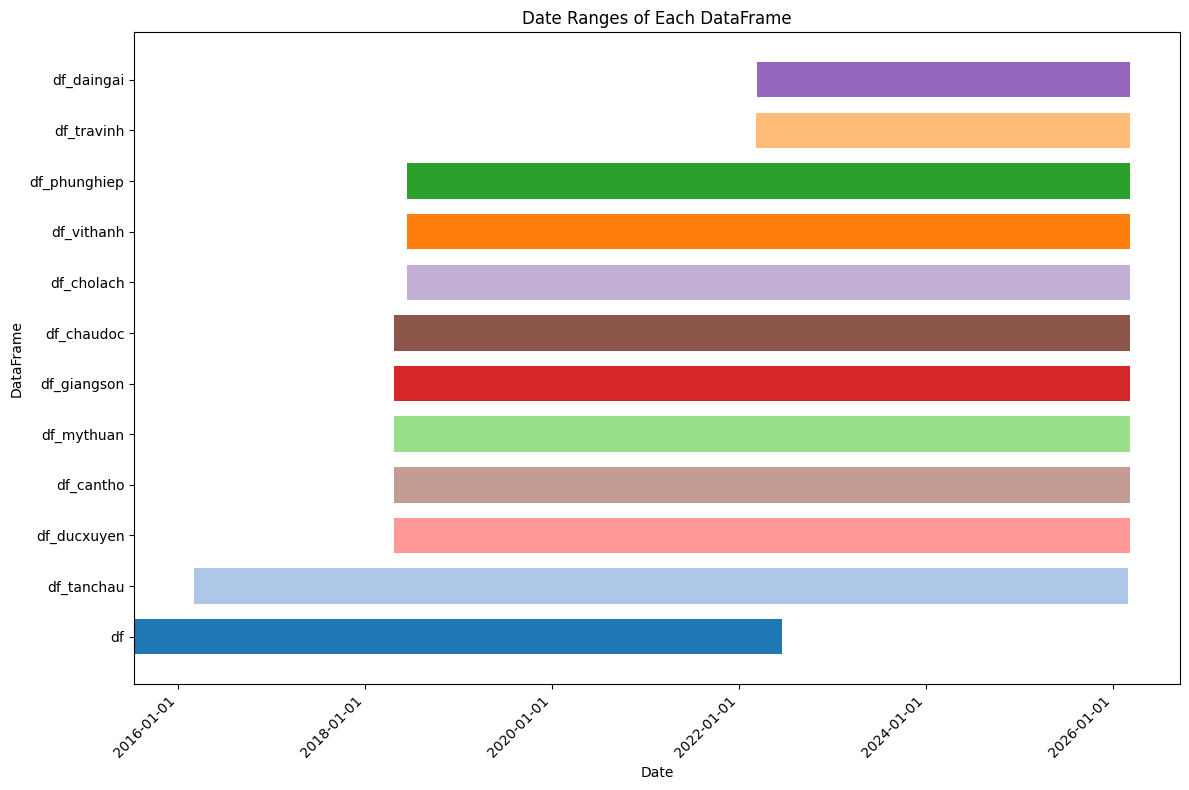

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Dictionary of dataframes and their date column names
dataframes_to_visualize = {
    'df': {'df_obj': df_clean, 'date_col': 'Date', 'date_format_hint': 'dayfirst'},
    'df_tanchau': {'df_obj': df_tanchau, 'date_col': 'ObservationDate'},
    'df_vithanh': {'df_obj': df_vithanh, 'date_col': 'ObservationDate'},
    'df_travinh': {'df_obj': df_travinh, 'date_col': 'ObservationDate'},
    'df_phunghiep': {'df_obj': df_phunghiep, 'date_col': 'ObservationDate'},
    'df_mythuan': {'df_obj': df_mythuan, 'date_col': 'ObservationDate'},
    'df_giangson': {'df_obj': df_giangson, 'date_col': 'ObservationDate'},
    'df_ducxuyen': {'df_obj': df_ducxuyen, 'date_col': 'ObservationDate'},
    'df_daingai': {'df_obj': df_daingai, 'date_col': 'ObservationDate'},
    'df_cholach': {'df_obj': df_cholach, 'date_col': 'ObservationDate'},
    'df_chaudoc': {'df_obj': df_chaudoc, 'date_col': 'ObservationDate'},
    'df_cantho': {'df_obj': df_cantho, 'date_col': 'ObservationDate'},
}

date_ranges = []

for name, data in dataframes_to_visualize.items():
    df_obj = data['df_obj']
    date_col = data['date_col']
    date_format_hint = data.get('date_format_hint')

    # Convert date column to datetime, coercing errors to NaT
    if date_format_hint == 'dayfirst':
        df_obj[date_col] = pd.to_datetime(df_obj[date_col], errors='coerce', dayfirst=True)
    else:
        df_obj[date_col] = pd.to_datetime(df_obj[date_col], errors='coerce')

    # Drop rows where date is NaT after conversion
    df_obj.dropna(subset=[date_col], inplace=True)

    if not df_obj.empty:
        min_date = df_obj[date_col].min()
        max_date = df_obj[date_col].max()
        date_ranges.append({'DataFrame': name, 'Start_Date': min_date, 'End_Date': max_date})
    else:
        print(f"Warning: DataFrame '{name}' is empty or has no valid dates after processing.")

df_date_ranges = pd.DataFrame(date_ranges)

# Sort by Start_Date for better visualization
df_date_ranges = df_date_ranges.sort_values(by='Start_Date')

print("Date ranges for each DataFrame:")
display(df_date_ranges)

# Plotting the date ranges
fig, ax = plt.subplots(figsize=(12, 8))

# Assign a unique color to each dataframe for better distinction
colors = plt.cm.tab20.colors # Using a colormap with enough distinct colors

for i, row in df_date_ranges.iterrows():
    start_date = row['Start_Date']
    end_date = row['End_Date']
    df_name = row['DataFrame']

    # Calculate the duration in days for bar width
    duration = (end_date - start_date).days

    # Plotting each range as a horizontal bar
    # Using start_date as the left edge, duration as width, and i for y-position
    ax.barh(df_name, duration, left=start_date, height=0.7,
            color=colors[i % len(colors)], label=f'{df_name}: {start_date.strftime("%Y-%m-%d")} to {end_date.strftime("%Y-%m-%d")}')

# Formatting the plot
ax.set_xlabel('Date')
ax.set_ylabel('DataFrame')
ax.set_title('Date Ranges of Each DataFrame')

# Format x-axis to show dates nicely
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45, ha='right')

# Adjust y-axis to show DataFrame names clearly
ax.set_yticks(range(len(df_date_ranges)))
ax.set_yticklabels(df_date_ranges['DataFrame'])

plt.tight_layout()
plt.show()

In [ ]:
df_tanchau['ObservationDate'].min()

Timestamp('2016-03-03 00:00:00')

In [ ]:
# df_clean = df_clean[df_clean['Date'] >= '2016-03-03'].copy()
# print(f"Số lượng bản ghi của df_clean sau khi lọc theo ngày: {len(df_clean)}")
# display(df_clean.head())

### Phân tích Tân Châu

In [ ]:
import pandas as pd

# 1. Ensure 'ObservationDate' is datetime and sort
df_tanchau['ObservationDate'] = pd.to_datetime(df_tanchau['ObservationDate'])
df_tanchau_sorted = df_tanchau.sort_values('ObservationDate').drop_duplicates(subset='ObservationDate')

# 2. Create complete daily date range
min_date = df_tanchau_sorted['ObservationDate'].min()
max_date = df_tanchau_sorted['ObservationDate'].max()
full_date_range = pd.date_range(start=min_date, end=max_date, freq='D')

# 3. Reindex to identify gaps
df_tanchau_gap = df_tanchau_sorted.set_index('ObservationDate').reindex(full_date_range)
df_tanchau_gap.index.name = 'Date'

# 4. Extract year and group
df_tanchau_gap['Year'] = df_tanchau_gap.index.year

# 5. Calculate annual missing data rates
annual_stats = df_tanchau_gap.groupby('Year').agg(
    Total_Days=('WaterLevel', 'size'),
    Present_Days=('WaterLevel', 'count')
)
annual_stats['Missing_Days'] = annual_stats['Total_Days'] - annual_stats['Present_Days']
annual_stats['Missing_Rate_Percent'] = (annual_stats['Missing_Days'] / annual_stats['Total_Days']) * 100

# 6. Print results
print(f"Tan Chau Water Level Missing Data Analysis ({min_date.date()} to {max_date.date()}):")
print(annual_stats[['Total_Days', 'Present_Days', 'Missing_Rate_Percent']])

significant_gaps = annual_stats[annual_stats['Missing_Rate_Percent'] > 5]
if not significant_gaps.empty:
    print("\nYears with significant data gaps (> 5%):")
    print(significant_gaps.index.tolist())
else:
    print("\nNo years found with significant data gaps (> 5%).")

Tan Chau Water Level Missing Data Analysis (2016-03-03 to 2026-03-01):
      Total_Days  Present_Days  Missing_Rate_Percent
Year                                                
2016         304           304              0.000000
2017         365           365              0.000000
2018         365           365              0.000000
2019         365           365              0.000000
2020         366           366              0.000000
2021         365           365              0.000000
2022         365           365              0.000000
2023         365           365              0.000000
2024         366           366              0.000000
2025         365           360              1.369863
2026          60            60              0.000000

No years found with significant data gaps (> 5%).


Descriptive Statistics for Tan Chau Water Level by Year:


,count,mean,std,min,max
Year,,,,,
2016,304,1.334737,0.872978,-0.09,3.00
2017,365,1.639342,0.958011,0.14,3.24
2018,365,1.633370,1.185908,0.03,4.03
2019,365,1.087425,0.795922,-0.03,3.46
2020,366,0.932732,0.825393,-0.54,2.69
2021,365,1.073781,0.794594,-0.37,2.63
2022,365,1.390795,0.964283,-0.12,3.55
2023,365,1.184274,0.944877,-0.63,3.01
2024,366,1.265437,0.848963,-0.06,3.23


/tmp/ipykernel_9115/1186341788.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x='Year', y='WaterLevel', data=df_tanchau_gap.dropna(subset=['WaterLevel']), palette='viridis')


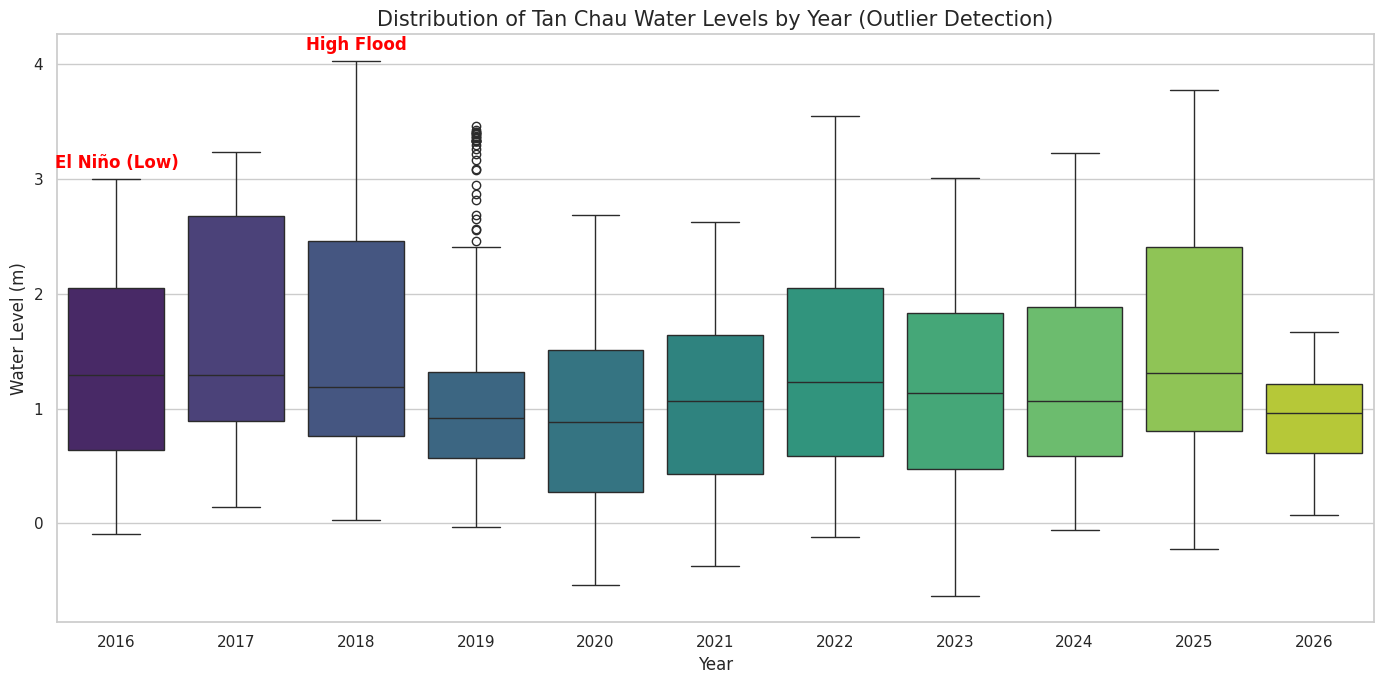

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate descriptive statistics grouped by Year
annual_desc_stats = df_tanchau_gap.groupby('Year')['WaterLevel'].agg(['count', 'mean', 'std', 'min', 'max'])
print("Descriptive Statistics for Tan Chau Water Level by Year:")
display(annual_desc_stats)

# 2. Visualization using Boxplot
plt.figure(figsize=(14, 7))
sns.set_theme(style="whitegrid")

ax = sns.boxplot(x='Year', y='WaterLevel', data=df_tanchau_gap.dropna(subset=['WaterLevel']), palette='viridis')

# 3. Add Titles and Labels
plt.title('Distribution of Tan Chau Water Levels by Year (Outlier Detection)', fontsize=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Water Level (m)', fontsize=12)

# 4. Annotate specific years (2016: El Niño/Low water, 2018: Flood year)
years_to_annotate = {2016: 'El Niño (Low)', 2018: 'High Flood'}

# Find positions of the years on the x-axis
year_positions = {label.get_text(): i for i, label in enumerate(ax.get_xticklabels())}

for year, label in years_to_annotate.items():
    year_str = str(year)
    if year_str in year_positions:
        pos = year_positions[year_str]
        # Get the max value for that year to place the text
        max_val = annual_desc_stats.loc[year, 'max']
        ax.text(pos, max_val + 0.1, label, horizontalalignment='center', color='red', weight='semibold')

plt.tight_layout()
plt.show()

### Xem xét df đích

### Lọc và phân tích dữ liệu đích

Phần này tập trung vào việc tiền xử lý và phân tích DataFrame đích (`df_target_filtered`):
1.  **Lọc theo ngày**: Chỉ giữ lại các bản ghi từ `2016-03-03` trở đi để đảm bảo tính đồng nhất về thời gian.
2.  **Kiểm tra thông tin DataFrame**: Sử dụng `df_target_filtered.info()` để xem cấu trúc sau khi lọc.
3.  **Thống kê mật độ dữ liệu theo tháng**: Tạo bảng pivot và heatmap để trực quan hóa số lượng mẫu theo năm và tháng, giúp xác định các khoảng thời gian có dữ liệu dày đặc hoặc thưa thớt.
4.  **Lọc theo mùa khô**: Giới hạn dữ liệu chỉ trong các tháng 3, 4, 5, 6 (mùa khô) để phù hợp với mục tiêu phân tích xâm nhập mặn.

In [ ]:
# 1. Lọc df_target từ 2016-03-03
df_target_filtered = df_clean[df_clean['Date'] >= '2016-03-03'].copy()

In [ ]:
df_target_filtered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2671 entries, 0 to 2695
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Matram     2671 non-null   object        
 1   longitude  2671 non-null   float64       
 2   latitude   2671 non-null   float64       
 3   Z.Elev     2671 non-null   float64       
 4   Date       2671 non-null   datetime64[ns]
 5   Salinity   2671 non-null   float64       
 6   CL         2671 non-null   float64       
 7   TSS        2671 non-null   float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 187.8+ KB


Thống kê số lượng dữ liệu mặn theo Năm và Tháng:


Month,1,2,3,4,5,6,7,9,11
Year,,,,,,,,,
2016,0,0,33,55,33,44,0,0,0
2017,0,0,60,60,60,60,0,0,0
2019,45,60,174,173,159,144,15,1,0
2020,12,54,113,31,129,99,0,0,0
2021,83,96,167,140,119,72,36,0,5
2022,17,40,96,81,51,54,0,0,0


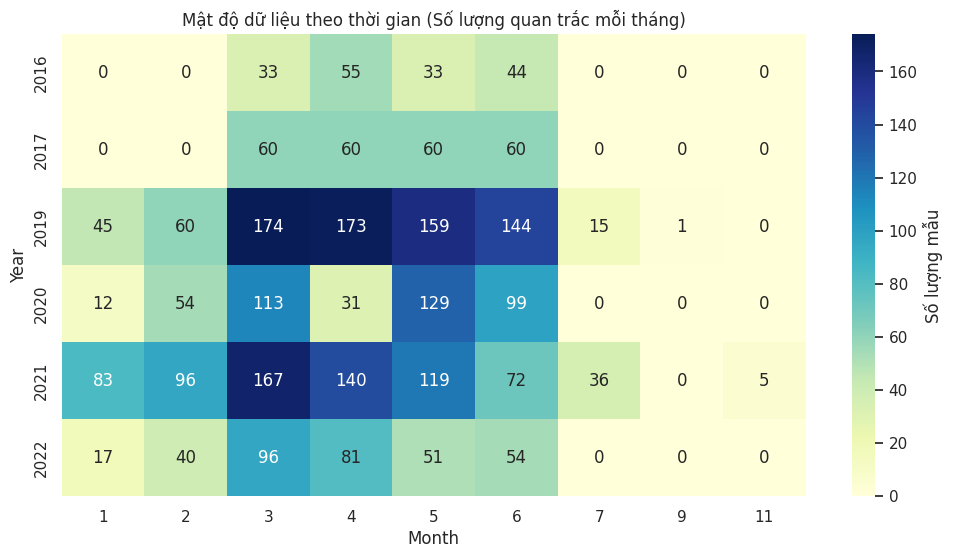

In [ ]:
import pandas as pd

# 1. Trích xuất Năm và Tháng từ cột Date
df_stats = df_target_filtered.copy()
df_stats['Year'] = df_stats['Date'].dt.year
df_stats['Month'] = df_stats['Date'].dt.month

# 2. Tạo bảng xoay (Pivot Table) để đếm số lượng bản ghi
# Dòng là Năm, Cột là Tháng
monthly_counts = df_stats.pivot_table(
    index='Year',
    columns='Month',
    values='Salinity',
    aggfunc='count',
    fill_value=0
)

print("Thống kê số lượng dữ liệu mặn theo Năm và Tháng:")
display(monthly_counts)

# 3. Trực quan hóa bằng Heatmap để dễ quan sát vùng thiếu dữ liệu
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(monthly_counts, annot=True, fmt='d', cmap='YlGnBu', cbar_kws={'label': 'Số lượng mẫu'})
plt.title('Mật độ dữ liệu theo thời gian (Số lượng quan trắc mỗi tháng)')
plt.show()

In [ ]:
# 1. Lọc dữ liệu chỉ lấy các tháng 3, 4, 5, 6
df_target_filtered = df_target_filtered[df_target_filtered['Date'].dt.month.isin([3, 4, 5, 6])].copy()

print(f"Số lượng bản ghi sau khi lọc mùa khô: {len(df_target_filtered)}")
display(df_target_filtered.head())

Số lượng bản ghi sau khi lọc mùa khô: 2207


,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS
0,BD00012019,106.58,10.43,0.95,2019-03-04,8.1,746.80,35.21
1,BD00012019,106.58,10.43,0.95,2019-03-18,9.0,921.00,25.12
2,BD00012019,106.58,10.43,0.95,2019-04-02,8.0,91.56,32.15
3,BD00012019,106.58,10.43,0.95,2019-04-16,9.4,1832.00,35.26
4,BD00012019,106.58,10.43,0.95,2019-05-01,6.7,1526.00,52.20


### Điền khuyết dữ liệu

### Điền khuyết dữ liệu mực nước bằng Covariate Matching

Phần này sử dụng kỹ thuật Covariate Matching để điền khuyết dữ liệu mực nước thiếu. Các bước chính bao gồm:
1.  **Tiền xử lý dữ liệu mực nước**: Hàm `quick_process_wl` chuẩn bị các DataFrame mực nước hàng ngày.
2.  **Mở rộng Feature Bank**: Tạo một DataFrame (`df_combined_wl`) chứa tất cả dữ liệu mực nước và các đặc trưng thời gian (DayOfYear, Month, cyclic features) để làm cơ sở tìm kiếm.
3.  **Xây dựng Candidate Pool**: Xác định các ngày có dữ liệu mực nước đầy đủ để tạo thành nhóm ứng cử viên cho việc so khớp.
4.  **Thực hiện Matching**: Sử dụng `StandardScaler` và `NearestNeighbors` để tìm `k` láng giềng gần nhất cho mỗi ngày có dữ liệu thiếu, sau đó điền khuyết cell-wise từ các láng giềng đã chọn.
5.  **Trực quan hóa**: So sánh phân phối dữ liệu mực nước trước và sau khi điền khuyết bằng biểu đồ KDE (Kernel Density Estimate) để đánh giá hiệu quả của phương pháp.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import random

# Helper function to process water level dataframes
def quick_process_wl(df_station, station_name):
    df_s = df_station.copy()
    df_s['ObservationDate'] = pd.to_datetime(df_s['ObservationDate'], errors='coerce')
    df_daily = df_s.groupby(df_s['ObservationDate'].dt.date).agg(
        WaterLevel_Mean=('WaterLevel', 'mean')
    ).reset_index()

    # 1. FIX: Đổi tên cột ObservationDate thành Date
    df_daily['Date'] = pd.to_datetime(df_daily['ObservationDate'])
    df_daily.drop(columns=['ObservationDate'], inplace=True)

    df_daily.rename(columns={'WaterLevel_Mean': f'{station_name}_WL'}, inplace=True)

    # 2. FIX: Set cột Date làm Index để dễ dàng Join
    df_daily.set_index('Date', inplace=True)
    return df_daily

# Define all stations based on available dataframes in the kernel
stations_to_process = ['TanChau', 'ViThanh', 'TraVinh', 'PhungHiep', 'MyThuan', 'GiangSon', 'DucXuyen', 'DaiNgai', 'ChoLach', 'ChauDoc', 'CanTho']

# Raw water level dataframes available in the kernel state
# Chú ý: Cần đảm bảo các df_tanchau, df_vithanh... đã được load vào bộ nhớ
water_level_sources = {
    'TanChau': df_tanchau,
    'ViThanh': df_vithanh,
    'TraVinh': df_travinh,
    'PhungHiep': df_phunghiep,
    'MyThuan': df_mythuan,
    'GiangSon': df_giangson,
    'DucXuyen': df_ducxuyen,
    'DaiNgai': df_daingai,
    'ChoLach': df_cholach,
    'ChauDoc': df_chaudoc,
    'CanTho': df_cantho,
}

# 0. Định nghĩa danh sách các cột mực nước
wl_cols = [f'{s}_WL' for s in stations_to_process]

# 1. Mở rộng Feature Bank cho Matching
start_date = '2016-03-03'
end_date = df_target_filtered['Date'].max() # Đảm bảo df_target_filtered đã tồn tại
full_range = pd.date_range(start=start_date, end=end_date, freq='D')

# Initialize df_combined_wl with the full date range as index
df_combined_wl = pd.DataFrame(index=full_range)
df_combined_wl.index.name = 'Date' # Cả 2 df bây giờ đều có chung index name là 'Date'

# Process each water level dataframe and merge into df_combined_wl
for name, dframe in water_level_sources.items():
    processed_df = quick_process_wl(dframe, name)

    # 3. FIX: Thay pd.merge bằng .join() do cả 2 đều đã được set index là Date
    df_combined_wl = df_combined_wl.join(processed_df, how='left')

X_search = df_combined_wl.copy()

# Tính trung bình dựa trên các trạm hiện có (partial truth)
X_search['Global_Mean_WL'] = X_search[wl_cols].mean(axis=1)

# Tạo cyclic features
X_search['DayOfYear'] = X_search.index.dayofyear
X_search['Month'] = X_search.index.month
X_search['Day_sin'] = np.sin(2 * np.pi * X_search['DayOfYear'] / 365.25)
X_search['Day_cos'] = np.cos(2 * np.pi * X_search['DayOfYear'] / 365.25)
X_search['Month_sin'] = np.sin(2 * np.pi * X_search['Month'] / 12)
X_search['Month_cos'] = np.cos(2 * np.pi * X_search['Month'] / 12)

features_for_matching = ['Global_Mean_WL', 'Day_sin', 'Day_cos', 'Month_sin', 'Month_cos']

# 2. Xây dựng Candidate Pool (Các ngày có dữ liệu 100% đầy đủ)
df_pool = X_search.dropna(subset=wl_cols).copy()

# 3. Thực hiện Matching với K láng giềng
scaler = StandardScaler()
scaled_pool = scaler.fit_transform(df_pool[features_for_matching])

k_neighbors = 5
nn = NearestNeighbors(n_neighbors=k_neighbors, metric='euclidean')
nn.fit(scaled_pool)

# Nội suy tạm thời Global_Mean để đảm bảo mọi dòng đều có đặc trưng để so khớp
X_search['Global_Mean_WL'] = X_search['Global_Mean_WL'].interpolate(method='linear')
scaled_all = scaler.transform(X_search[features_for_matching])
distances, indices = nn.kneighbors(scaled_all)

# --- BƯỚC 4 CẢI TIẾN: ĐIỀN KHUYẾT CHỌN LỌC (CELL-WISE) ---
# Khởi tạo df kết quả từ dữ liệu gốc
df_wl_imputed = df_combined_wl.copy()

for i, date in enumerate(df_combined_wl.index):
    # Kiểm tra xem dòng hiện tại có bất kỳ giá trị NaN nào không
    if df_combined_wl.loc[date, wl_cols].isna().any():
        # Chọn ngẫu nhiên 1 trong k láng giềng gần nhất
        chosen_neighbor_idx = random.choice(indices[i])
        matched_date = df_pool.index[chosen_neighbor_idx]

        # Lấy giá trị của láng giềng "hiến tặng"
        donor_values = df_pool.loc[matched_date, wl_cols]

        # CHỈ ĐIỀN VÀO Ô TRỐNG: fillna sẽ giữ lại giá trị thực và chỉ thay thế NaN
        df_wl_imputed.loc[date, wl_cols] = df_wl_imputed.loc[date, wl_cols].fillna(donor_values)

print("Đã điền khuyết thành công!")

Đã điền khuyết thành công!


In [ ]:
df_wl_imputed.tail()

,TanChau_WL,ViThanh_WL,TraVinh_WL,PhungHiep_WL,MyThuan_WL,GiangSon_WL,DucXuyen_WL,DaiNgai_WL,ChoLach_WL,ChauDoc_WL,CanTho_WL
Date,,,,,,,,,,,
2022-06-13,1.47,0.297716,0.220833,0.465453,0.276083,-0.001,21.655635,0.115948,0.206000,1.063792,0.502698
2022-06-14,1.43,0.328147,0.304635,0.529156,0.349187,-0.001,21.480292,0.237521,0.282305,1.130656,0.581927
2022-06-15,1.22,0.353687,0.361365,0.557781,0.377240,-0.001,21.214802,0.275854,0.325156,1.166125,0.609479
2022-06-16,0.77,0.344563,0.372229,0.571600,0.374094,-0.001,21.171771,0.267202,0.322927,1.163844,0.608177
2022-06-17,0.36,0.358167,0.404469,0.581284,0.391188,-0.001,21.162302,0.295863,0.346062,1.163094,0.622948


### Biểu đồ phân phối trước và sau khi điền khuyết

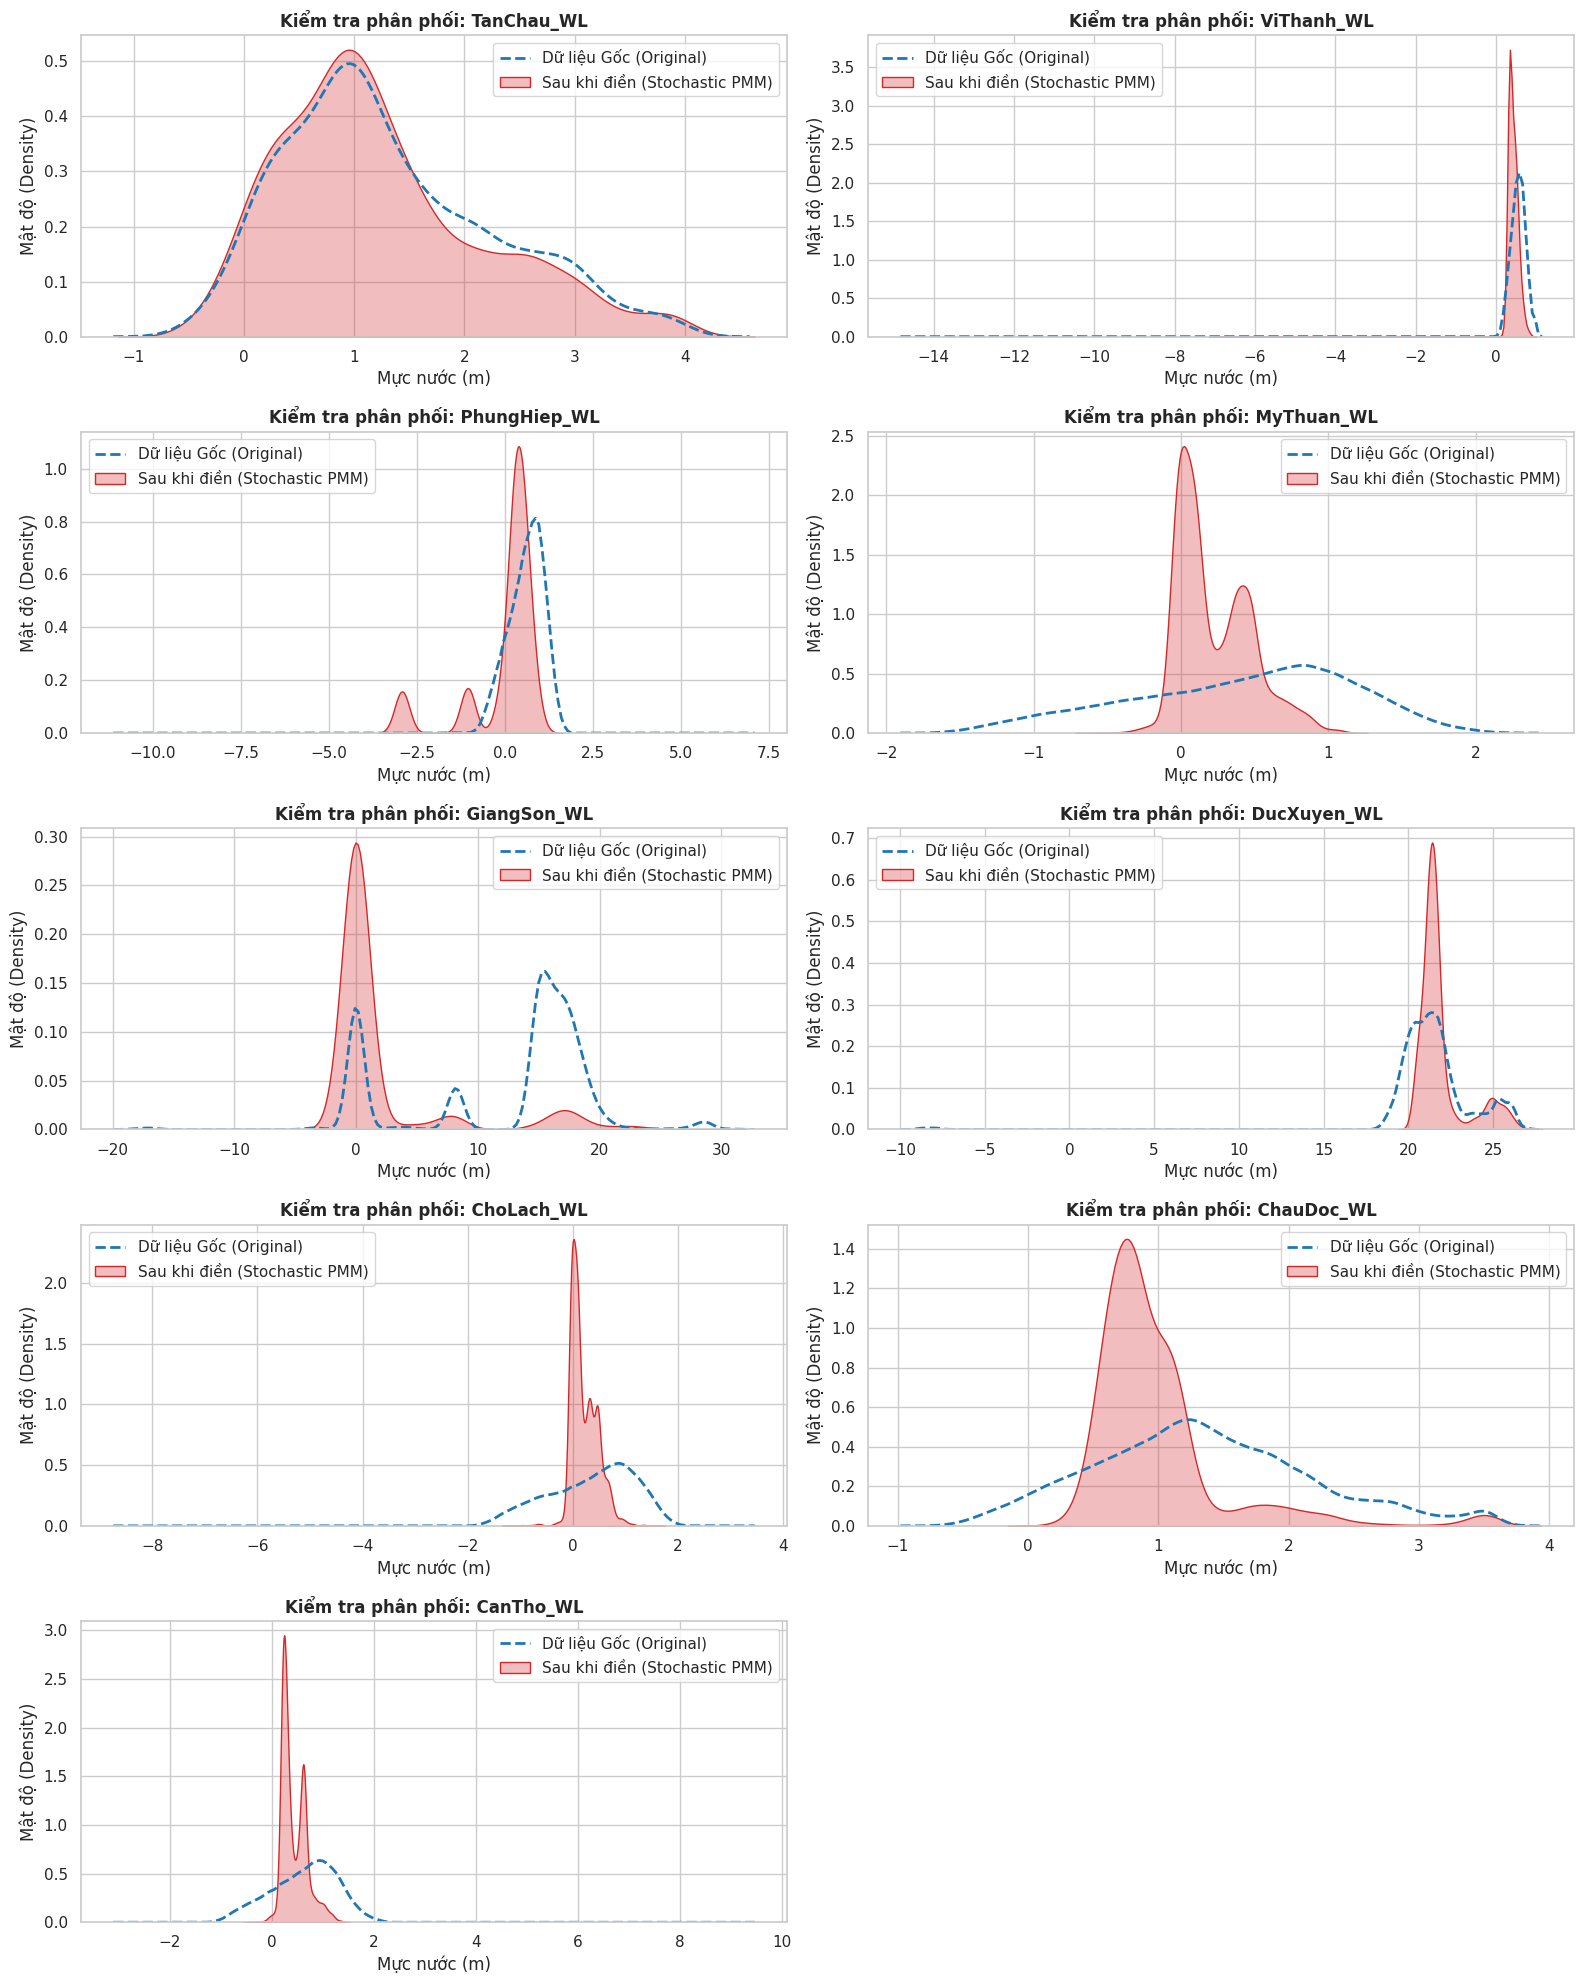

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Danh sách các trạm cần so sánh
stations_to_compare = {
    'TanChau_WL': df_tanchau,
    'ViThanh_WL': df_vithanh,
    'PhungHiep_WL': df_phunghiep,
    'MyThuan_WL': df_mythuan,
    'GiangSon_WL': df_giangson,
    'DucXuyen_WL': df_ducxuyen,
    'ChoLach_WL': df_cholach,
    'ChauDoc_WL': df_chaudoc,
    'CanTho_WL': df_cantho
}

# Thiết lập layout
plt.figure(figsize=(16, 20))
sns.set_style("whitegrid")

for i, (col_name, df_orig) in enumerate(stations_to_compare.items(), 1):
    ax = plt.subplot(5, 2, i)

    # Vẽ phân phối dữ liệu gốc (Màu xanh - Đường đứt nét)
    sns.kdeplot(df_orig['WaterLevel'].dropna(),
                label='Dữ liệu Gốc (Original)',
                color='#1f77b4', linestyle='--', linewidth=2, ax=ax)

    # Vẽ phân phối dữ liệu sau khi điền khuyết (Màu đỏ - Vùng phủ)
    sns.kdeplot(df_wl_imputed[col_name],
                label='Sau khi điền (Stochastic PMM)',
                color='#d62728', alpha=0.3, fill=True, ax=ax)

    ax.set_title(f'Kiểm tra phân phối: {col_name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Mực nước (m)')
    ax.set_ylabel('Mật độ (Density)')
    ax.legend()

plt.tight_layout()
plt.savefig('distribution_comparison.png', dpi=300)
plt.show()

Quan sát biểu đồ, bạn có thể thấy rằng phân phối dữ liệu sau khi điền khuyết đã lấp đầy các khoảng trống và trở nên mượt mà hơn, đặc biệt là ở các giá trị có nhiều dữ liệu bị thiếu.

### Kỹ thuật Feature Engineering: Đặc trưng không gian và thời gian

Phần này tập trung vào việc tạo ra các đặc trưng mới để nâng cao khả năng của mô hình:
1.  **Đặc trưng trễ (Lagged Features)**: Tạo các cột mực nước trễ (ví dụ: `TanChau_WL_lag1`, `TanChau_WL_lag2`,...) cho tất cả các trạm thủy văn, phản ánh trạng thái thủy văn trong quá khứ.
2.  **Đặc trưng thời gian (Cyclic Features)**: Chuyển đổi `Month` và `DayOfYear` thành các đặc trưng hình sin/cos (`Month_sin`, `Month_cos`, `DayOfYear_sin`, `DayOfYear_cos`) để bắt được tính chu kỳ của thời gian.
3.  **Khoảng cách đến cửa biển và Tân Châu**: Tính toán khoảng cách địa lý từ mỗi điểm quan trắc đến cửa biển gần nhất (`Dist_to_Sea_km`) và đến trạm Tân Châu (`Dist_to_TanChau_km`), sử dụng hàm Haversine và hệ số uốn khúc sông.
4.  **Gán nhãn Proxy và Trọng số**: Tạo cờ `is_proxy` và `sample_weight` để phân biệt các bản ghi gốc và các bản ghi được điền khuyết (proxy), có thể sử dụng trong quá trình huấn luyện mô hình.

In [ ]:
df_tanchau.head()

,ObservationDate,WaterLevel
0,2016-03-03,0.52
1,2016-03-04,0.66
2,2016-03-05,0.74
3,2016-03-06,0.81
4,2016-03-07,0.93


In [ ]:
import pandas as pd
import numpy as np

# 1. Xác định danh sách cột mực nước từ df_wl_imputed
wl_cols = [col for col in df_wl_imputed.columns if '_WL' in col]
lags = [1, 2, 3, 4, 5, 6, 7]  # Lấy mảng trễ 7 ngày từ Đoạn 2

# 2. Tạo DataFrame chứa các đặc trưng trễ
wl_lagged_features = df_wl_imputed.copy()

for col in wl_cols:
    for lag in lags:
        wl_lagged_features[f'{col}_lag{lag}'] = wl_lagged_features[col].shift(lag)

# 3. Chuẩn bị final_df từ df_target_filtered (Bộ khung CHUẨN chứa Không gian & Thời gian)
# FIX: Xóa đoạn tạo full_range trống và sử dụng trực tiếp df_target_filtered
final_df = df_target_filtered.copy()

final_df['Month'] = final_df['Date'].dt.month
final_df['DayOfYear'] = final_df['Date'].dt.dayofyear

# Mã hóa vòng lặp (Cyclic Encoding)
final_df['Month_sin'] = np.sin(2 * np.pi * final_df['Month'] / 12)
final_df['Month_cos'] = np.cos(2 * np.pi * final_df['Month'] / 12)
final_df['DayOfYear_sin'] = np.sin(2 * np.pi * final_df['DayOfYear'] / 365)
final_df['DayOfYear_cos'] = np.cos(2 * np.pi * final_df['DayOfYear'] / 365)

# Khoảng cách đường sông đến cửa biển
sea_mouth = {'latitude': 9.3, 'longitude': 106.5}
final_df['Dist_to_Sea_km'] = final_df.apply(
    lambda row: haversine_distance(row['latitude'], row['longitude'], sea_mouth['latitude'], sea_mouth['longitude']),
    axis=1
) * SINUOSITY_INDEX

# Khoảng cách đến trạm Tân Châu
tan_chau_coords = {'latitude': 10.80062, 'longitude': 105.24802}
final_df['Dist_to_TanChau_km'] = final_df.apply(
    lambda row: haversine_distance(row['latitude'], row['longitude'], tan_chau_coords['latitude'], tan_chau_coords['longitude']),
    axis=1
) * SINUOSITY_INDEX

# 4. Gộp toàn bộ các mức trễ vào dữ liệu mặn
# Đảm bảo wl_to_merge có cột Date
if wl_lagged_features.index.name != 'Date':
    wl_to_merge = wl_lagged_features.reset_index().rename(columns={'index': 'Date'})
else:
    wl_to_merge = wl_lagged_features.reset_index()

# ==========================================
# FIX: Dọn dẹp các ngày bị trùng lặp trong dữ liệu mực nước
# ==========================================
so_dong_bi_trung = wl_to_merge['Date'].duplicated().sum()
if so_dong_bi_trung > 0:
    print(f"Phát hiện {so_dong_bi_trung} ngày bị trùng lặp trong dữ liệu thủy văn. Đang tiến hành loại bỏ...")
    # Chỉ giữ lại bản ghi đầu tiên của mỗi ngày
    wl_to_merge = wl_to_merge.drop_duplicates(subset=['Date'], keep='first')

# Thực hiện gộp dữ liệu
final_df = pd.merge(final_df, wl_to_merge, on='Date', how='left')

# 5. Gán nhãn Proxy và Trọng số
original_dates = df_target_filtered['Date'].unique()
final_df['is_proxy'] = ~final_df['Date'].isin(original_dates)
final_df['sample_weight'] = np.where(final_df['is_proxy'], 0.7, 1.0)

print(f"Hoàn tất tạo đặc trưng đa tầng trễ. Số lượng cột: {len(final_df.columns)}")
display(final_df.head())

Hoàn tất tạo đặc trưng đa tầng trễ. Số lượng cột: 106


,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS,Month,DayOfYear,...,ChauDoc_WL_lag7,CanTho_WL_lag1,CanTho_WL_lag2,CanTho_WL_lag3,CanTho_WL_lag4,CanTho_WL_lag5,CanTho_WL_lag6,CanTho_WL_lag7,is_proxy,sample_weight
0,BD00012019,106.58,10.43,0.95,2019-03-04,8.1,746.80,35.21,3,63,...,0.726448,0.304896,0.383573,0.386625,0.448490,0.496510,0.427344,0.393063,False,1.0
1,BD00012019,106.58,10.43,0.95,2019-03-18,9.0,921.00,25.12,3,77,...,0.674146,0.640208,0.196281,-0.030091,0.396635,0.400635,0.374260,0.346354,False,1.0
2,BD00012019,106.58,10.43,0.95,2019-04-02,8.0,91.56,32.15,4,92,...,1.115833,0.719333,0.732365,-0.182029,0.345156,0.442115,0.546844,0.518375,False,1.0
3,BD00012019,106.58,10.43,0.95,2019-04-16,9.4,1832.00,35.26,4,106,...,0.496208,0.299115,0.299115,0.640208,0.299115,0.299115,0.240917,0.196281,False,1.0
4,BD00012019,106.58,10.43,0.95,2019-05-01,6.7,1526.00,52.20,5,121,...,0.611260,0.150938,0.129229,0.182229,0.684192,0.640208,0.299115,0.240917,False,1.0


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2207 entries, 0 to 2206
Columns: 106 entries, Matram to sample_weight
dtypes: bool(1), datetime64[ns](1), float64(101), int32(2), object(1)
memory usage: 1.8+ MB


In [ ]:
final_df['sample_weight'].unique()

array([1.])

### Tính khoảng cách đến cửa biển gần nhất

Phần này xác định các cửa sông chính trong khu vực và sử dụng hàm `haversine_distance` cùng với `SINUOSITY_INDEX` để tính toán khoảng cách ngắn nhất từ mỗi điểm quan trắc đến một trong các cửa sông này. Kết quả được lưu vào cột mới `Dist_to_Sea_Nearest`.

In [ ]:
river_mouths = [
    # --- HỆ THỐNG SÔNG TIỀN ---
    {"name": "Cua Tieu", "lat": 10.250, "lon": 106.750},
    {"name": "Cua Dai", "lat": 10.200, "lon": 106.700},
    {"name": "Cua Ham Luong", "lat": 10.050, "lon": 106.590},
    {"name": "Cua Co Chien", "lat": 9.940, "lon": 106.520},
    {"name": "Cua Cung Hau", "lat": 9.870, "lon": 106.570},

    # --- HỆ THỐNG SÔNG HẬU ---
    {"name": "Cua Dinh An", "lat": 9.550, "lon": 106.330},
    {"name": "Cua Tran De", "lat": 9.470, "lon": 106.210},

    # --- VÙNG BÁN ĐẢO CÀ MAU & BIỂN ĐÔNG ---
    {"name": "Cua Ganh Hao", "lat": 9.025, "lon": 105.420},
    {"name": "Cua Bo De", "lat": 8.740, "lon": 105.230},
    {"name": "Mui Ca Mau", "lat": 8.610, "lon": 104.720}, # Điểm cực Nam

    # --- VÙNG BIỂN TÂY (VỊNH THÁI LAN) ---
    {"name": "Cua Song Doc", "lat": 9.175, "lon": 104.805},
    {"name": "Cua Cai Lon", "lat": 9.870, "lon": 105.010},
    {"name": "Rach Gia", "lat": 10.010, "lon": 105.060},
    {"name": "Ha Tien", "lat": 10.370, "lon": 104.470}
]

def calculate_nearest_sea_distance(row, river_mouths, sinuosity_index):
    min_dist = float('inf')
    for mouth in river_mouths:
        dist = haversine_distance(row['latitude'], row['longitude'], mouth['lat'], mouth['lon'])
        min_dist = min(min_dist, dist)
    return min_dist * sinuosity_index

# Áp dụng hàm để tạo trường mới 'Dist_to_Sea_Nearest'
# final_df đã được định nghĩa ở các bước trước
final_df['Dist_to_Sea_Nearest'] = final_df.apply(
    lambda row: calculate_nearest_sea_distance(row, river_mouths, SINUOSITY_INDEX),
    axis=1
)

print("Đã thêm trường 'Dist_to_Sea_Nearest' vào final_df.")
print(final_df[['latitude', 'longitude', 'Dist_to_Sea_Nearest']].head())

Đã thêm trường 'Dist_to_Sea_Nearest' vào final_df.
   latitude  longitude  Dist_to_Sea_Nearest
0     10.43     106.58            35.516899
1     10.43     106.58            35.516899
2     10.43     106.58            35.516899
3     10.43     106.58            35.516899
4     10.43     106.58            35.516899


In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2207 entries, 0 to 2206
Columns: 107 entries, Matram to Dist_to_Sea_Nearest
dtypes: bool(1), datetime64[ns](1), float64(102), int32(2), object(1)
memory usage: 1.8+ MB


### Xử lý giá trị thiếu cuối cùng (NaNs)

Sau tất cả các bước tiền xử lý và tạo đặc trưng, phần này kiểm tra xem còn bất kỳ giá trị `NaN` nào trong DataFrame `final_df` hay không. Nếu có, các hàng chứa `NaN` sẽ được loại bỏ (`dropna()`) để đảm bảo DataFrame sạch sẽ trước khi đưa vào huấn luyện mô hình.

In [ ]:
nan_records_r1 = final_df[final_df.isna().any(axis=1)]
print(f"Số lượng bản ghi có NaN trong final_df: {len(nan_records_r1)}")
display(nan_records_r1)

Số lượng bản ghi có NaN trong final_df: 11


,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS,Month,DayOfYear,...,CanTho_WL_lag1,CanTho_WL_lag2,CanTho_WL_lag3,CanTho_WL_lag4,CanTho_WL_lag5,CanTho_WL_lag6,CanTho_WL_lag7,is_proxy,sample_weight,Dist_to_Sea_Nearest
1527,TGLX012016,105.06,10.44,1.24,2016-03-04,0.032971,18.25,6.50,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,62.157964
1572,TGLX022016,105.10,10.71,1.94,2016-03-04,0.038518,21.32,4.80,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,101.347116
1617,TGLX032016,105.13,10.27,-1.20,2016-03-04,0.002818,1.56,16.21,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,38.881404
1662,TGLX042016,105.06,10.44,1.24,2016-03-04,0.025871,14.32,19.21,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,62.157964
1707,TGLX052016,104.87,10.51,1.92,2016-03-04,0.004354,2.41,2.56,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,60.357964
1752,TGLX062016,104.64,10.53,0.33,2016-03-04,0.042529,23.54,24.50,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,33.450680
1797,TGLX072016,105.09,10.02,0.38,2016-03-04,0.020614,11.41,16.40,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,4.508539
1842,TGLX082016,104.93,10.19,0.58,2016-03-04,5.900000,3241.00,26.40,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,31.926429
1887,TGLX092016,104.74,10.28,0.57,2016-03-04,0.044480,24.62,32.48,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,40.541534
1932,TGLX102016,104.52,10.37,0.25,2016-03-04,2.400000,135.00,4.21,3,64,...,0.196281,NaN,NaN,NaN,NaN,NaN,NaN,False,1.0,7.109612


In [ ]:
final_df = final_df.dropna().reset_index(drop=True)
print(f"Số lượng bản ghi sau khi xóa các hàng có NaN: {len(final_df)}")
display(final_df.head())

Số lượng bản ghi sau khi xóa các hàng có NaN: 2196


,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS,Month,DayOfYear,...,CanTho_WL_lag1,CanTho_WL_lag2,CanTho_WL_lag3,CanTho_WL_lag4,CanTho_WL_lag5,CanTho_WL_lag6,CanTho_WL_lag7,is_proxy,sample_weight,Dist_to_Sea_Nearest
0,BD00012019,106.58,10.43,0.95,2019-03-04,8.1,746.80,35.21,3,63,...,0.304896,0.383573,0.386625,0.448490,0.496510,0.427344,0.393063,False,1.0,35.516899
1,BD00012019,106.58,10.43,0.95,2019-03-18,9.0,921.00,25.12,3,77,...,0.640208,0.196281,-0.030091,0.396635,0.400635,0.374260,0.346354,False,1.0,35.516899
2,BD00012019,106.58,10.43,0.95,2019-04-02,8.0,91.56,32.15,4,92,...,0.719333,0.732365,-0.182029,0.345156,0.442115,0.546844,0.518375,False,1.0,35.516899
3,BD00012019,106.58,10.43,0.95,2019-04-16,9.4,1832.00,35.26,4,106,...,0.299115,0.299115,0.640208,0.299115,0.299115,0.240917,0.196281,False,1.0,35.516899
4,BD00012019,106.58,10.43,0.95,2019-05-01,6.7,1526.00,52.20,5,121,...,0.150938,0.129229,0.182229,0.684192,0.640208,0.299115,0.240917,False,1.0,35.516899


### Tạo đặc trưng thống kê cửa sổ trượt cho mực nước Tân Châu

Phần này tính toán các thống kê cửa sổ trượt (rolling window statistics) cho mực nước của trạm Tân Châu (`TanChau_WL`). Cụ thể, nó tính toán giá trị trung bình (`mean`), độ lệch chuẩn (`std`), và giá trị lớn nhất (`max`) trong vòng 7 ngày gần nhất. Các đặc trưng này giúp mô hình nắm bắt xu hướng và biến động ngắn hạn của mực nước.

In [ ]:
import pandas as pd

# 1. Calculate rolling 7-day statistics for TanChau_WL from df_wl_imputed
# Create a temporary DataFrame for these calculations to avoid modifying df_wl_imputed directly
temp_tanchau_stats = df_wl_imputed[['TanChau_WL']].copy()

# Calculate rolling mean, std, and max over a 7-day window
temp_tanchau_stats['TanChau_mean_7d'] = temp_tanchau_stats['TanChau_WL'].rolling(window='7D').mean()
temp_tanchau_stats['TanChau_std_7d'] = temp_tanchau_stats['TanChau_WL'].rolling(window='7D').std()
temp_tanchau_stats['TanChau_max_7d'] = temp_tanchau_stats['TanChau_WL'].rolling(window='7D').max()

# Drop the original 'TanChau_WL' from this temporary dataframe if not needed for merging
temp_tanchau_stats = temp_tanchau_stats.drop(columns=['TanChau_WL'])

# 2. Merge these new features into final_df
# Ensure 'Date' in final_df is datetime type for merging
final_df['Date'] = pd.to_datetime(final_df['Date'])

# Merge based on the 'Date' index of temp_tanchau_stats and 'Date' column of final_df
final_df = pd.merge(final_df, temp_tanchau_stats.reset_index(), on='Date', how='left')

print(f"Các trường mới đã được thêm vào final_df. Kích thước DataFrame mới: {final_df.shape}")
display(final_df.head())

Các trường mới đã được thêm vào final_df. Kích thước DataFrame mới: (2196, 110)


,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS,Month,DayOfYear,...,CanTho_WL_lag4,CanTho_WL_lag5,CanTho_WL_lag6,CanTho_WL_lag7,is_proxy,sample_weight,Dist_to_Sea_Nearest,TanChau_mean_7d,TanChau_std_7d,TanChau_max_7d
0,BD00012019,106.58,10.43,0.95,2019-03-04,8.1,746.80,35.21,3,63,...,0.448490,0.496510,0.427344,0.393063,False,1.0,35.516899,0.705714,0.246567,0.95
1,BD00012019,106.58,10.43,0.95,2019-03-18,9.0,921.00,25.12,3,77,...,0.396635,0.400635,0.374260,0.346354,False,1.0,35.516899,0.517143,0.384392,1.06
2,BD00012019,106.58,10.43,0.95,2019-04-02,8.0,91.56,32.15,4,92,...,0.345156,0.442115,0.546844,0.518375,False,1.0,35.516899,0.642857,0.189096,0.96
3,BD00012019,106.58,10.43,0.95,2019-04-16,9.4,1832.00,35.26,4,106,...,0.299115,0.299115,0.240917,0.196281,False,1.0,35.516899,0.382857,0.302639,0.82
4,BD00012019,106.58,10.43,0.95,2019-05-01,6.7,1526.00,52.20,5,121,...,0.684192,0.640208,0.299115,0.240917,False,1.0,35.516899,0.458571,0.183251,0.77


In [ ]:
for i in final_df.columns:
  print(i)

Matram
longitude
latitude
Z.Elev
Date
Salinity
CL
TSS
Month
DayOfYear
Month_sin
Month_cos
DayOfYear_sin
DayOfYear_cos
Dist_to_Sea_km
Dist_to_TanChau_km
TanChau_WL
ViThanh_WL
TraVinh_WL
PhungHiep_WL
MyThuan_WL
GiangSon_WL
DucXuyen_WL
DaiNgai_WL
ChoLach_WL
ChauDoc_WL
CanTho_WL
TanChau_WL_lag1
TanChau_WL_lag2
TanChau_WL_lag3
TanChau_WL_lag4
TanChau_WL_lag5
TanChau_WL_lag6
TanChau_WL_lag7
ViThanh_WL_lag1
ViThanh_WL_lag2
ViThanh_WL_lag3
ViThanh_WL_lag4
ViThanh_WL_lag5
ViThanh_WL_lag6
ViThanh_WL_lag7
TraVinh_WL_lag1
TraVinh_WL_lag2
TraVinh_WL_lag3
TraVinh_WL_lag4
TraVinh_WL_lag5
TraVinh_WL_lag6
TraVinh_WL_lag7
PhungHiep_WL_lag1
PhungHiep_WL_lag2
PhungHiep_WL_lag3
PhungHiep_WL_lag4
PhungHiep_WL_lag5
PhungHiep_WL_lag6
PhungHiep_WL_lag7
MyThuan_WL_lag1
MyThuan_WL_lag2
MyThuan_WL_lag3
MyThuan_WL_lag4
MyThuan_WL_lag5
MyThuan_WL_lag6
MyThuan_WL_lag7
GiangSon_WL_lag1
GiangSon_WL_lag2
GiangSon_WL_lag3
GiangSon_WL_lag4
GiangSon_WL_lag5
GiangSon_WL_lag6
GiangSon_WL_lag7
DucXuyen_WL_lag1
DucXuyen_WL_la

In [ ]:
import folium
import pandas as pd
import numpy as np

# 1. Lấy dữ liệu trạm duy nhất từ final_df
# Đảm bảo chỉ lấy các hàng duy nhất dựa trên Matram, latitude, longitude
df_stations = final_df[['Matram', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)

# 2. Trích xuất mã trạm (phần chữ cái đầu) từ cột 'Matram'
df_stations['Ma_Tram_Goc'] = df_stations['Matram'].apply(lambda x: ''.join(filter(str.isalpha, x))).str.upper()

# 3. Tạo một bản đồ Folium
# Tính toán tọa độ trung bình để căn giữa bản đồ
center_lat = df_stations['latitude'].mean()
center_lon = df_stations['longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=8)

# 4. Gán màu sắc duy nhất cho mỗi Mã Trạm Gốc
unique_ma_tram = df_stations['Ma_Tram_Goc'].unique()
# Sử dụng một colormap để có đủ màu sắc khác nhau
colors = plt.cm.get_cmap('tab20', len(unique_ma_tram))

color_map_ma_tram = {ma_tram: 'rgb({},{},{})'.format(
    int(c[0]*255), int(c[1]*255), int(c[2]*255))
    for ma_tram, c in zip(unique_ma_tram, colors.colors)}

# 5. Thêm các điểm đánh dấu (marker) vào bản đồ
for idx, row in df_stations.iterrows():
    ma_tram = row['Ma_Tram_Goc']
    color = color_map_ma_tram.get(ma_tram, '#808080') # Màu xám mặc định nếu không tìm thấy

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color=color,
        fill=True,
        fill_color=color,
        fill_opacity=0.7,
        popup=f"Trạm: {row['Matram']}<br>Mã: {ma_tram}<br>Lat: {row['latitude']}<br>Lon: {row['longitude']}"
    ).add_to(m)

# Hiển thị bản đồ
m

/tmp/ipykernel_9115/1164479405.py:21: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab20', len(unique_ma_tram))


In [ ]:
# # Xóa các cột không cần thiết cho việc huấn luyện mô hình
# # Giữ lại CL vì đây là một thông số môi trường quan trọng và có thể là biến mục tiêu hoặc đặc trưng.
# final_df_reduced = final_df.drop(columns=['Matram', 'Date', 'is_proxy'])

# print("Đã xóa các cột Matram, Date và is_proxy.")
# print(f"Kích thước DataFrame mới: {final_df_reduced.shape}")
# display(final_df_reduced.head())

In [ ]:
df_wl_imputed.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2298 entries, 2016-03-03 to 2022-06-17
Freq: D
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TanChau_WL    2298 non-null   float64
 1   ViThanh_WL    2298 non-null   float64
 2   TraVinh_WL    2298 non-null   float64
 3   PhungHiep_WL  2298 non-null   float64
 4   MyThuan_WL    2298 non-null   float64
 5   GiangSon_WL   2298 non-null   float64
 6   DucXuyen_WL   2298 non-null   float64
 7   DaiNgai_WL    2298 non-null   float64
 8   ChoLach_WL    2298 non-null   float64
 9   ChauDoc_WL    2298 non-null   float64
 10  CanTho_WL     2298 non-null   float64
dtypes: float64(11)
memory usage: 280.0 KB


### Tạo đặc trưng Anomaly (chuẩn hóa theo khí hậu)

Phần này tạo ra các đặc trưng "anomaly" (độ bất thường) cho mực nước của tất cả các trạm. Phương pháp này bao gồm:
1.  **Tính toán khí hậu học hàng ngày**: Xác định giá trị mực nước trung bình theo ngày trong năm (`DayOfYear`) dựa trên dữ liệu lịch sử (`df_wl_imputed`).
2.  **Tính Anomaly**: Trừ đi giá trị trung bình khí hậu học tương ứng từ mực nước hiện tại để có được độ bất thường. Điều này được áp dụng cho cả mực nước hiện tại và các đặc trưng trễ (`TanChau_lagX_Anomaly`), giúp mô hình tập trung vào sự sai lệch so với điều kiện bình thường.

In [ ]:
# 1. Tính toán mực nước trung bình theo từng ngày trong năm (Day of Year) từ df_wl_imputed
# Sử dụng df_wl_imputed để lấy lịch sử đầy đủ cho tính toán climatology
df_climatology_source = df_wl_imputed.copy()

# df_wl_imputed đã có Date làm index, nên trích xuất DayOfYear trực tiếp từ index
if 'DayOfYear' not in df_climatology_source.columns:
    df_climatology_source['DayOfYear'] = df_climatology_source.index.dayofyear

# Danh sách các trạm
stations = ['TanChau', 'ViThanh', 'TraVinh', 'PhungHiep', 'MyThuan', 'GiangSon', 'DucXuyen', 'DaiNgai', 'ChoLach', 'ChauDoc', 'CanTho']

# FIX Bước 1: Group by DayOfYear để lấy giá trị trung bình lịch sử cho TẤT CẢ CÁC TRẠM cùng lúc
wl_cols_to_group = [f'{st}_WL' for st in stations]
# Code của bạn: daily_avg_climatology = df_climatology_source.groupby('DayOfYear')['TanChau_WL'].mean().reset_index()
# Chuyển thành:
daily_avg_climatology = df_climatology_source.groupby('DayOfYear')[wl_cols_to_group].mean()
# (Hàm groupby mặc định đã set DayOfYear làm index, nên không cần reset_index rồi set_index lại nữa)

# 2. Tạo DataFrame mới để tính toán Anomaly dựa trên final_df
df_anomaly = final_df.copy()

# Các mức lag tương ứng
lags = [1, 2, 3, 4, 5, 6, 7]

# 3. Tính toán Anomaly cho lag 0 và các mức lag khác
for st in stations:
    wl_col_base = f'{st}_WL'

    if wl_col_base in df_anomaly.columns: # Giữ nguyên logic an toàn

        # FIX Bước 3: Ánh xạ giá trị trung bình lịch sử của ĐÚNG TRẠM ĐÓ vào df_anomaly
        # Thay vì: daily_avg_climatology['TanChau_WL_Avg_Climatology']
        df_anomaly[f'{wl_col_base}_Avg'] = df_anomaly['DayOfYear'].map(daily_avg_climatology[wl_col_base])

        # Tính Anomaly cho Lag 0
        df_anomaly[f'{st}_Anomaly'] = df_anomaly[wl_col_base] - df_anomaly[f'{wl_col_base}_Avg']

        # Tính Anomaly cho các mức Lag (1, 2, 3, 4, 5, 6, 7)
        for lag in lags:
            lag_col = f'{wl_col_base}_lag{lag}'
            if lag_col in df_anomaly.columns:
                # Tính Anomaly cho cột trễ
                df_anomaly[f'{st}_lag{lag}_Anomaly'] = df_anomaly[lag_col] - df_anomaly[f'{wl_col_base}_Avg']

# 4. Xóa các cột mực nước tuyệt đối cũ và các cột trung bình tạm thời
cols_to_drop = []
for st in stations:
    cols_to_drop.append(f'{st}_WL_Avg')

# Chỉ drop những cột thực sự tồn tại
existing_drops = [c for c in cols_to_drop if c in df_anomaly.columns]
df_anomaly_final = df_anomaly.drop(columns=existing_drops)

print("Đã hoàn thành tính toán Anomaly (chuẩn từng trạm) và các mức trễ.")
print(f"Kích thước DataFrame mới: {df_anomaly_final.shape}")
display(df_anomaly_final.tail())

Đã hoàn thành tính toán Anomaly (chuẩn từng trạm) và các mức trễ.
Kích thước DataFrame mới: (2196, 198)


/tmp/ipykernel_9115/2155942425.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_anomaly[f'{st}_lag{lag}_Anomaly'] = df_anomaly[lag_col] - df_anomaly[f'{wl_col_base}_Avg']
/tmp/ipykernel_9115/2155942425.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_anomaly[f'{st}_lag{lag}_Anomaly'] = df_anomaly[lag_col] - df_anomaly[f'{wl_col_base}_Avg']
/tmp/ipykernel_9115/2155942425.py:43: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor perform

,Matram,longitude,latitude,Z.Elev,Date,Salinity,CL,TSS,Month,DayOfYear,...,ChauDoc_lag6_Anomaly,ChauDoc_lag7_Anomaly,CanTho_Anomaly,CanTho_lag1_Anomaly,CanTho_lag2_Anomaly,CanTho_lag3_Anomaly,CanTho_lag4_Anomaly,CanTho_lag5_Anomaly,CanTho_lag6_Anomaly,CanTho_lag7_Anomaly
2191,VC00102021,106.26,11.08,0.72,2021-04-26,0.012827,7.1,21.9,4,116,...,-0.030382,0.312753,-0.134568,-0.089933,-0.031735,0.309359,-0.112454,-0.031735,-0.031735,0.309359
2192,VC00102021,106.26,11.08,0.72,2021-05-11,0.100000,19.9,8.8,5,131,...,-0.036501,0.030040,0.054939,0.092179,0.092179,0.054939,0.396033,-0.014134,-0.003259,0.054939
2193,VC00102021,106.26,11.08,0.72,2021-05-26,0.035952,19.9,17.0,5,146,...,-0.093352,0.316325,0.010817,0.351910,-0.069902,-0.069902,-0.047381,-0.047381,-0.047381,0.351910
2194,VC00102021,106.26,11.08,0.72,2021-06-10,0.051309,28.4,11.3,6,161,...,-0.112981,-0.112981,-0.014137,0.006143,0.373311,-0.025981,0.373311,-0.025981,-0.025981,-0.025981
2195,VC00102021,106.26,11.08,0.72,2021-06-23,0.023125,12.8,9.9,6,174,...,-0.526886,-0.212524,-0.073168,0.079373,-0.084814,0.079373,-0.073168,-0.062293,-0.430993,-0.070106


In [ ]:
df_anomaly_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2196 entries, 0 to 2195
Columns: 198 entries, Matram to CanTho_lag7_Anomaly
dtypes: bool(1), datetime64[ns](1), float64(193), int32(2), object(1)
memory usage: 3.3+ MB


### Tạo đặc trưng tương tác: Sức mạnh Biển so với Sức mạnh Sông

Phần này tạo một đặc trưng tương tác quan trọng `Interaction_Sea_TanChau`, đại diện cho tỷ lệ giữa "sức mạnh của biển" và "sức mạnh của sông". Cụ thể, nó chia `Dist_to_Sea_Nearest` (khoảng cách đến biển) cho `TanChau_lag5_Anomaly` (độ bất thường của mực nước Tân Châu trễ 5 ngày, sau khi chuẩn hóa để tránh chia cho 0). Đặc trưng này nhằm mục đích thể hiện mức độ xâm nhập mặn thông qua sự cạnh tranh giữa áp lực thủy triều và dòng chảy ngọt.

In [ ]:
df_final_data = df_anomaly_final.copy() # Start with df_anomaly_final

if 'Dist_to_Sea_Nearest' in df_final_data.columns and 'TanChau_lag5_Anomaly' in df_final_data.columns:
    # Calculate min from the entire 'df_final_data' DataFrame for the purpose of this standalone cell.
    # Note: If 'df_final_data' is later split into train/test, calculating min from the whole
    # DataFrame before splitting could lead to data leakage. However, this adheres
    # to the instruction to use df_anomaly_final as input and produce 'df_final_data' within
    # the scope of this isolated cell where X_train/X_test are not available.
    tanchau_min_value = df_final_data['TanChau_lag5_Anomaly'].min()

    base_tanchau = df_final_data['TanChau_lag5_Anomaly'] - tanchau_min_value + 1
    # Handle potential division by zero by replacing 0 with a small non-zero number
    base_tanchau = base_tanchau.replace(0, 0.001)

    df_final_data['Interaction_Sea_TanChau'] = df_final_data['Dist_to_Sea_Nearest'] / base_tanchau

print("Created 'Interaction_Sea_TanChau' feature.")
print(f"New shape of 'df_final_data' DataFrame: {df_final_data.shape}")

Created 'Interaction_Sea_TanChau' feature.
New shape of 'df_final_data' DataFrame: (2196, 199)


### Lưu và tải lại dữ liệu đã xử lý

Phần này lưu DataFrame `df_final_data` (chứa tất cả các đặc trưng đã được kỹ sư hóa và xử lý) vào một tệp CSV trong Google Drive. Sau đó, nó tải lại tệp này vào một DataFrame mới (`final_df_reduced`) để đảm bảo rằng tất cả các bước tiền xử lý đã được áp dụng và sẵn sàng cho các bước huấn luyện mô hình tiếp theo, tránh các vấn đề tiềm ẩn từ việc giữ DataFrame trong bộ nhớ.

In [ ]:
# import os

# # Lưu file cuối cùng vào Google Drive
# output_path = '/content/drive/MyDrive/XNM/final_processed_data/final_processed_data_v2.csv'
# os.makedirs(os.path.dirname(output_path), exist_ok=True)

# df_final_data.to_csv(output_path, index=False, encoding='utf-8-sig')

# print(f"Thành công! Đã lưu dữ liệu tổng hợp tại: {output_path}")
# print(f"Kích thước dữ liệu cuối cùng: {df_final_data.shape}")

Thành công! Đã lưu dữ liệu tổng hợp tại: /content/drive/MyDrive/XNM/final_processed_data/final_processed_data_v2.csv
Kích thước dữ liệu cuối cùng: (2196, 199)


In [ ]:
import pandas as pd
final_df_reduced = pd.read_csv('/content/drive/MyDrive/XNM/final_processed_data/final_processed_data_v2.csv')

In [ ]:
for i in final_df_reduced.columns:
  print(i)

Matram
longitude
latitude
Z.Elev
Date
Salinity
CL
TSS
Month
DayOfYear
Month_sin
Month_cos
DayOfYear_sin
DayOfYear_cos
Dist_to_Sea_km
Dist_to_TanChau_km
TanChau_WL
ViThanh_WL
TraVinh_WL
PhungHiep_WL
MyThuan_WL
GiangSon_WL
DucXuyen_WL
DaiNgai_WL
ChoLach_WL
ChauDoc_WL
CanTho_WL
TanChau_WL_lag1
TanChau_WL_lag2
TanChau_WL_lag3
TanChau_WL_lag4
TanChau_WL_lag5
TanChau_WL_lag6
TanChau_WL_lag7
ViThanh_WL_lag1
ViThanh_WL_lag2
ViThanh_WL_lag3
ViThanh_WL_lag4
ViThanh_WL_lag5
ViThanh_WL_lag6
ViThanh_WL_lag7
TraVinh_WL_lag1
TraVinh_WL_lag2
TraVinh_WL_lag3
TraVinh_WL_lag4
TraVinh_WL_lag5
TraVinh_WL_lag6
TraVinh_WL_lag7
PhungHiep_WL_lag1
PhungHiep_WL_lag2
PhungHiep_WL_lag3
PhungHiep_WL_lag4
PhungHiep_WL_lag5
PhungHiep_WL_lag6
PhungHiep_WL_lag7
MyThuan_WL_lag1
MyThuan_WL_lag2
MyThuan_WL_lag3
MyThuan_WL_lag4
MyThuan_WL_lag5
MyThuan_WL_lag6
MyThuan_WL_lag7
GiangSon_WL_lag1
GiangSon_WL_lag2
GiangSon_WL_lag3
GiangSon_WL_lag4
GiangSon_WL_lag5
GiangSon_WL_lag6
GiangSon_WL_lag7
DucXuyen_WL_lag1
DucXuyen_WL_la

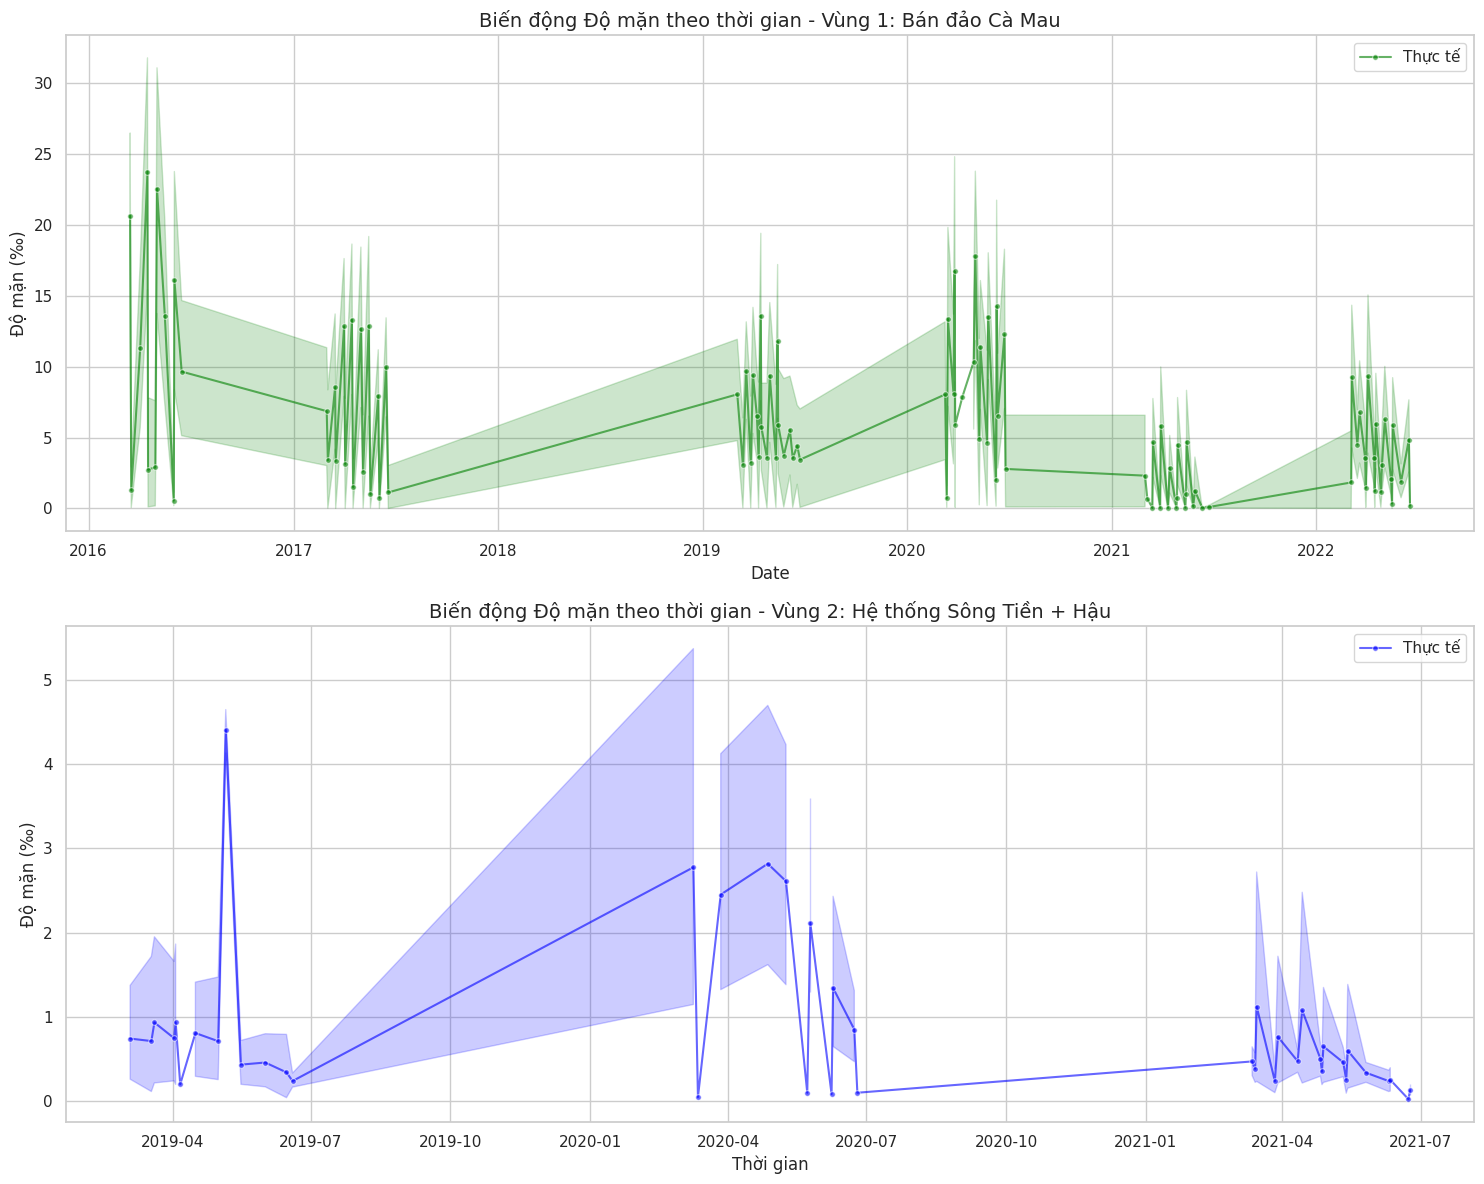

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Use df_anomaly_final as the base for plotting
df_plot = df_anomaly_final.copy()

# Re-introduce 'Date' and 'Matram' columns from final_df, which are index-aligned
df_plot['Date'] = df_anomaly_final['Date']
df_plot['Matram'] = df_anomaly_final['Matram']

# Ensure 'Date' is datetime (it should be already but good practice)
df_plot['Date'] = pd.to_datetime(df_plot['Date'])

# Add the 'Region' column to df_plot
# The function classify_region_numeric is assumed to be defined in a previous cell (Hukj5vW79E3N)
df_plot['Region'] = df_plot.apply(lambda row: classify_region_numeric(row['latitude'], row['longitude']), axis=1)

# Sort by Date for correct line plotting
df_plot = df_plot.sort_values('Date')

# 2. Thiết lập biểu đồ
plt.figure(figsize=(15, 12))
sns.set_theme(style="whitegrid")

# Vùng 1: Bán đảo Cà Mau
plt.subplot(2, 1, 1)
data_r1 = df_plot[df_plot['Region'] == 1]
sns.lineplot(data=data_r1, x='Date', y='Salinity', color='green', marker='o', markersize=4, alpha=0.6, label='Thực tế')
plt.title('Biến động Độ mặn theo thời gian - Vùng 1: Bán đảo Cà Mau', fontsize=14)
plt.ylabel('Độ mặn (‰)')

# Vùng 2: Hệ thống Sông Cửu Long
plt.subplot(2, 1, 2)
data_r2 = df_plot[df_plot['Region'] == 2]
sns.lineplot(data=data_r2, x='Date', y='Salinity', color='blue', marker='o', markersize=4, alpha=0.6, label='Thực tế')
plt.title('Biến động Độ mặn theo thời gian - Vùng 2: Hệ thống Sông Tiền + Hậu', fontsize=14)
plt.ylabel('Độ mặn (‰)')
plt.xlabel('Thời gian')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd

# 1. Lấy 2 mảng dữ liệu (đảm bảo cùng chiều dài)
arr1 = df_target_filtered['Date'].values[:len(df_anomaly_final)]
arr2 = df_anomaly_final['Date'].values

# 2. Đưa vào chung 1 DataFrame
df_compare = pd.DataFrame({
    'Date_Target': arr1,
    'Date_Anomaly': arr2
})

# 3. Lọc ra những dòng có giá trị khác nhau
df_diff = df_compare[df_compare['Date_Target'] != df_compare['Date_Anomaly']]

print(f"Tổng số vị trí bị lệch: {len(df_diff)}")
if len(df_diff) > 0:
    print("\nChi tiết các dòng bị lệch:")
    display(df_diff) # Dùng print(df_diff) nếu bạn không chạy trên Jupyter Notebook
else:
    print("Hai mảng hoàn toàn khớp nhau 100%!")

Tổng số vị trí bị lệch: 669

Chi tiết các dòng bị lệch:


,Date_Target,Date_Anomaly
1527,2016-03-04,2016-03-17
1528,2016-03-17,2016-04-02
1529,2016-04-02,2016-04-16
1530,2016-04-16,2016-04-29
1531,2016-04-29,2016-05-16
...,...,...
2191,2021-03-12,2021-04-26
2192,2021-03-27,2021-05-11
2193,2021-04-11,2021-05-26
2194,2021-04-26,2021-06-10


In [ ]:
import folium
import pandas as pd

# 1. Lấy dữ liệu trạm đo mặn từ final_df_reduced
# Đảm bảo chỉ lấy các hàng duy nhất dựa trên Matram, latitude, longitude
df_salinity_stations = final_df_reduced[['Matram', 'latitude', 'longitude']].drop_duplicates().reset_index(drop=True)

# 2. Tạo một bản đồ Folium, lấy trung tâm từ các trạm đo mặn
center_lat = df_salinity_stations['latitude'].mean()
center_lon = df_salinity_stations['longitude'].mean()
m = folium.Map(location=[center_lat, center_lon], zoom_start=8)

# 3. Thêm các trạm đo mặn (màu xanh lá đậm)
for idx, row in df_salinity_stations.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=6,
        color='#006400', # Dark Green
        fill=True,
        fill_color='#006400',
        fill_opacity=0.7,
        popup=f"Trạm: {row['Matram']}<br>Lat: {row['latitude']}<br>Lon: {row['longitude']}"
    ).add_to(m)

# 4. Thêm trạm Tân Châu (hình ngôi sao)
# Tọa độ Tân Châu đã được định nghĩa ở cell SbYitZ8b--ES
tan_chau_coords = {'latitude': 10.80062, 'longitude': 105.24802}
folium.Marker(
    location=[tan_chau_coords['latitude'], tan_chau_coords['longitude']],
    icon=folium.Icon(color='red', icon='star'), # Red star icon
    popup=f"Trạm Tân Châu<br>Lat: {tan_chau_coords['latitude']}<br>Lon: {tan_chau_coords['longitude']}"
).add_to(m)

# 5. Thêm các tọa độ ven biển trong river_mouths (màu xanh nước biển đậm)
# river_mouths đã được định nghĩa ở cell PrehaXfWFnzE
river_mouths = [
     # --- HỆ THỐNG SÔNG TIỀN ---
    {"name": "Cua Tieu", "lat": 10.250, "lon": 106.750},
    {"name": "Cua Dai", "lat": 10.200, "lon": 106.700},
    {"name": "Cua Ham Luong", "lat": 10.050, "lon": 106.590},
    {"name": "Cua Co Chien", "lat": 9.940, "lon": 106.520},
    {"name": "Cua Cung Hau", "lat": 9.870, "lon": 106.570},

    # --- HỆ THỐNG SÔNG HẬU ---
    {"name": "Cua Dinh An", "lat": 9.550, "lon": 106.330},
    {"name": "Cua Tran De", "lat": 9.470, "lon": 106.210},

    # --- VÙNG BÁN ĐẢO CÀ MAU & BIỂN ĐÔNG ---
    {"name": "Cua Ganh Hao", "lat": 9.025, "lon": 105.420},
    {"name": "Cua Bo De", "lat": 8.740, "lon": 105.230},
    {"name": "Mui Ca Mau", "lat": 8.610, "lon": 104.720}, # Điểm cực Nam

    # --- VÙNG BIỂN TÂY (VỊNH THÁI LAN) ---
    {"name": "Cua Song Doc", "lat": 9.175, "lon": 104.805},
    {"name": "Cua Cai Lon", "lat": 9.870, "lon": 105.010},
    {"name": "Rach Gia", "lat": 10.010, "lon": 105.060},
    {"name": "Ha Tien", "lat": 10.370, "lon": 104.470}
]

for mouth in river_mouths:
    folium.CircleMarker(
        location=[mouth['lat'], mouth['lon']],
        radius=5,
        color='#FF0000', # Dark Blue
        fill=True,
        fill_color='#FF0000',
        fill_opacity=0.8,
        popup=f"Cửa sông: {mouth['name']}<br>Lat: {mouth['lat']}<br>Lon: {mouth['lon']}"
    ).add_to(m)

# Hiển thị bản đồ
m